# Bias Classification using Internal Attention Representations

## Abstract
This notebook explores the capability of BERT's internal attention mechanisms to detect biased statements *without* fine-tuning the model weights. We extract granular attention features from a pre-trained `bert-base-uncased` model and use them to train classifiers. The workflow includes rigorous validation, hyperparameter tuning, and advanced interpretability techniques.

## Methodology
1. **Setup and Imports**: Load required libraries and configure environment.
2. **Data Loading**: Load the bias classification dataset.
3. **Feature Extraction**: Extract ~2,000 attention features (GAM, Head Spec, ISA, Tree) per sentence.
4. **Preprocessing and EDA**: Remove constant features and visualize using PCA and t-SNE.
5. **Model Selection and Optimization**:
    - 5.1 Train/Test Split (80/20)
    - 5.2 Model Comparison via Cross-Validation
    - 5.3 Hyperparameter Tuning with HalvingRandomSearchCV
    - 5.4 Learning Curves for overfitting detection
6. **Final Model Evaluation**: Performance on held-out test set.
7. **Counterfactual Analysis**: Interpret decisions via nearest counterfactuals.
8. **Feature Importance Analysis**:
    - 8.1 Permutation Importance
    - 8.2 Feature Stability Analysis
    - 8.3 SHAP Values and Consensus Ranking
9. **TF-IDF Baseline Comparison**: Compare against text-based baseline.
10. **Scientific Validation**: Bootstrap CIs, calibration, threshold analysis, error analysis.

# 1. Setup and Imports

In [1]:
import subprocess
import sys
import os

try:
    import spacy
    if not spacy.util.is_package("en_core_web_sm"):
        subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
except Exception as e:
    print(f"Spacy setup warning: {e}")

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import re

# ML Imports
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, GroupShuffleSplit,
    cross_val_predict, train_test_split, GridSearchCV,
    HalvingRandomSearchCV, cross_validate
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Project Imports
current_dir = os.getcwd()
if 'attention_app' in current_dir:
    while 'attention_app' in current_dir and os.path.basename(current_dir) != 'attention-atlas':
        current_dir = os.path.dirname(current_dir)
    root_dir = current_dir
else:
    root_dir = current_dir

if root_dir not in sys.path: sys.path.append(root_dir)

from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence
sns.set_theme(style="whitegrid", context="notebook")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 2. Data Loading

Load the bias classification dataset.

In [3]:
# Load Data
dataset_path = os.path.join(root_dir, 'dataset', 'bias_sentences_mixed_5700.json')
with open(dataset_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_sentences = pd.DataFrame(data['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)
print(f"Total Samples: {len(df_sentences)}")
print(df_sentences['label'].value_counts())

# Diagnostic: text duplication analysis
n_unique_texts = df_sentences['text'].nunique()
n_total = len(df_sentences)
print(f"\nDuplicate Analysis:")
print(f"  Total rows: {n_total}")
print(f"  Unique texts: {n_unique_texts} ({n_total - n_unique_texts} duplicates)")

# Drop exact duplicate rows (same text + same label + same metadata)
df_sentences = df_sentences.drop_duplicates().reset_index(drop=True)
n_after_dedup = len(df_sentences)
n_still_dup = n_after_dedup - df_sentences['text'].nunique()
print(f"  After drop_duplicates(): {n_after_dedup} rows")
print(f"  Texts still appearing >1 time: {n_still_dup}")
print(f"  -> Group-based splitting will be used to prevent leakage")

Total Samples: 5700
label
0    2850
1    2850
Name: count, dtype: int64

Duplicate Analysis:
  Total rows: 5700
  Unique texts: 5700 (0 duplicates)
  After drop_duplicates(): 5700 rows
  Texts still appearing >1 time: 0
  -> Group-based splitting will be used to prevent leakage


# 3. Feature Extraction

Extract attention-based features from BERT in batches to manage memory usage.

In [4]:
# Feature Extraction (Batched Processing)
# Process data in batches of 500 to prevent memory issues

BATCH_SIZE = 500
model_name = "bert-base-uncased"
manager = ModelManager()

# Calculate number of batches
total_samples = len(df_sentences)
num_batches = (total_samples + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Processing {total_samples} samples in {num_batches} batches of up to {BATCH_SIZE} samples each...")

# Store batch results
batch_dfs = []

# Process each batch
for batch_idx in range(num_batches):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, total_samples)
    
    print(f"\nBatch {batch_idx + 1}/{num_batches}: Processing samples {start_idx} to {end_idx-1}...")
    
    # Extract features for current batch
    feature_rows = []
    batch_df = df_sentences.iloc[start_idx:end_idx]
    
    for index, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc=f"Batch {batch_idx + 1}"):
        try:
            feats = extract_features_for_sentence(row['text'], model_name, manager)
            feats['label'] = row['label']
            feature_rows.append(feats)
        except Exception as e:
            print(f"  Skipping sample {index}: {e}")
    
    # Create DataFrame for this batch
    batch_df_features = pd.DataFrame(feature_rows).fillna(0)
    batch_dfs.append(batch_df_features)
    
    print(f"  Batch {batch_idx + 1} completed: {batch_df_features.shape[0]} samples, {batch_df_features.shape[1]} features")
    
    # Clear variables to free memory
    del feature_rows, batch_df_features

# Concatenate all batches
print("\n Combining all batches...")
df_features = pd.concat(batch_dfs, ignore_index=True)

print(f"\nFeature extraction completed!")
print(f"Final Feature Matrix: {df_features.shape[0]} samples × {df_features.shape[1]} features")


Processing 5700 samples in 12 batches of up to 500 samples each...

Batch 1/12: Processing samples 0 to 499...


Batch 1:   0%|          | 0/500 [00:00<?, ?it/s]

Loading model: bert-base-uncased...
  Batch 1 completed: 500 samples, 3239 features

Batch 2/12: Processing samples 500 to 999...


Batch 2:   0%|          | 0/500 [00:00<?, ?it/s]

  Batch 2 completed: 500 samples, 3239 features

Batch 3/12: Processing samples 1000 to 1499...


...

  Batch 10 completed: 500 samples, 3239 features

Batch 11/12: Processing samples 5000 to 5499...


Batch 11:   0%|          | 0/500 [00:00<?, ?it/s]

  Batch 11 completed: 500 samples, 3239 features

Batch 12/12: Processing samples 5500 to 5699...


Batch 12:   0%|          | 0/200 [00:00<?, ?it/s]

  Batch 12 completed: 200 samples, 3239 features

 Combining all batches...

Feature extraction completed!
Final Feature Matrix: 5700 samples × 3239 features


### Save Features

In [5]:
# Save Feature Matrix (Simple Version)
import os

# Create output directory
output_dir = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features')
os.makedirs(output_dir, exist_ok=True)


# Save as Pickle (recommended for faster loading)
output_path_pkl = os.path.join(output_dir, 'feature_matrix_bert_mixed_5700.pkl')
df_features.to_pickle(output_path_pkl)
print(f"Feature matrix saved to: {output_path_pkl}")

Feature matrix saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\extracted_features\feature_matrix_bert_mixed_5700.pkl


### Load Features

In [4]:
# Load Previously Saved Feature Matrix
manager = ModelManager()
# Load from pickle (faster)
features_path = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features', 'feature_matrix_bert_mixed_5700.pkl')

if os.path.exists(features_path):
    df_features = pd.read_pickle(features_path)
    print(f"Loaded feature matrix: {df_features.shape[0]} samples x {df_features.shape[1]} features")

    # Align text column from df_sentences for group-based splitting
    # Feature matrix rows correspond to df_sentences rows by position
    if len(df_features) == len(df_sentences):
        df_features['text'] = df_sentences['text'].values
        df_features['id'] = df_sentences['id'].values if 'id' in df_sentences.columns else range(len(df_features))
        print(f"  Aligned text column for group-based splitting")
        print(f"  Unique texts in features: {df_features['text'].nunique()} / {len(df_features)}")
    else:
        print(f"  WARNING: Feature matrix ({len(df_features)}) and df_sentences ({len(df_sentences)}) size mismatch.")
        print(f"  Using row index as group key (less protection against leakage).")
        df_features['text'] = [f'row_{i}' for i in range(len(df_features))]
        df_features['id'] = range(len(df_features))
else:
    print("Feature matrix file not found. Please run feature extraction first.")

Loaded feature matrix: 5700 samples x 3239 features
  Aligned text column for group-based splitting
  Unique texts in features: 5700 / 5700


# 4. Preprocessing and Exploratory Data Analysis

Remove constant features and visualize the feature space using dimensionality reduction.

Total features: 3238
Total samples: 5700
Unique groups (texts): 5700
EDA preview - features after VT(0.01): 3238 -> 417


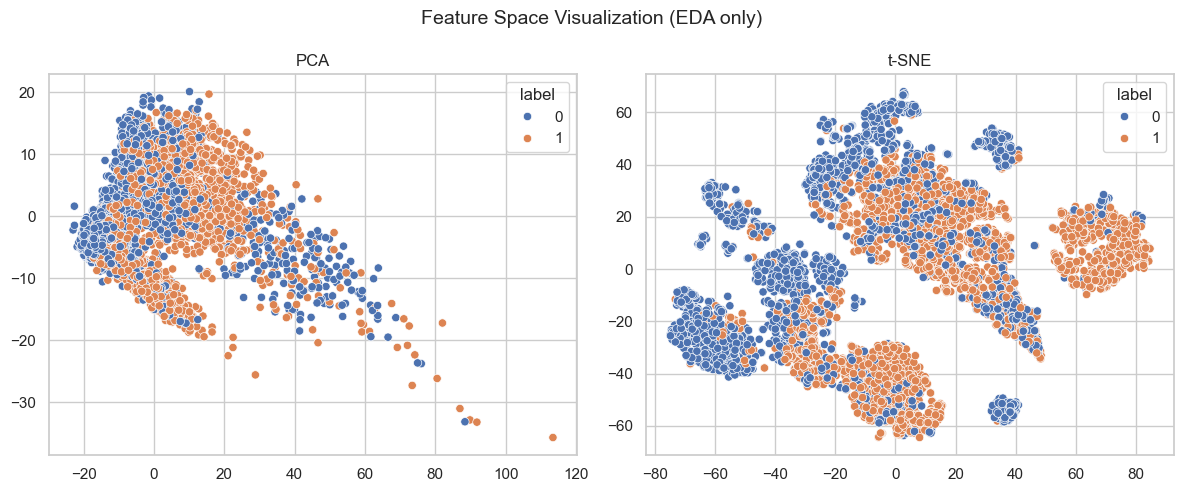

In [5]:
# Separate features and labels
drop_cols = ['label', 'id', 'text', 'original_id']
X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label']

# Text-based groups for leakage-free splitting
# All rows with the same text get the same group ID
text_to_group = {t: i for i, t in enumerate(df_features['text'].unique())}
groups = df_features['text'].map(text_to_group).values

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print(f"Unique groups (texts): {len(text_to_group)}")

# NOTE: VarianceThreshold is now inside the ML pipeline (fit on train only)
# to prevent data leakage. Below is EDA-only visualization.

# Temporary VT for EDA visualization only (does NOT affect modeling)
_vt_eda = VarianceThreshold(threshold=0.01)
X_eda = _vt_eda.fit_transform(X)
_eda_feats = X.columns[_vt_eda.get_support()]
print(f"EDA preview - features after VT(0.01): {X.shape[1]} -> {len(_eda_feats)}")

# X_final: keeps all features (pipeline handles VT internally)
X_final = X.copy()

# Scaling for EDA
scaler_eda = StandardScaler()
X_scaled = scaler_eda.fit_transform(X_eda)

# PCA & t-SNE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, ax=ax[0])
ax[0].set_title('PCA')
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, ax=ax[1])
ax[1].set_title('t-SNE')
plt.suptitle('Feature Space Visualization (EDA only)', fontsize=14)
plt.tight_layout()
plt.show()

del X_eda, _vt_eda, scaler_eda, X_scaled, X_pca, X_tsne

# 5. Model Selection and Optimization

## 5.1 Group-Based Train/Test Split

Hold out 20% of the data for final evaluation using **group-based splitting** (GroupShuffleSplit).
All instances of the same text are assigned to the same split, preventing data leakage from duplicate sentences.

In [6]:
# Group-based split: all instances of the same text go to the same fold
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_final, y, groups=groups))

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Groups for the training set (needed for group-aware cross-validation)
groups_train = groups[train_idx]

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set:  {X_test.shape[0]} samples")

# Verify no text overlap between train and test
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts = set(df_features.iloc[test_idx]['text'])
overlap = train_texts & test_texts
print(f"\nLeakage Check:")
print(f"  Unique texts in train: {len(train_texts)}")
print(f"  Unique texts in test:  {len(test_texts)}")
print(f"  Text overlap: {len(overlap)} (should be 0)")
assert len(overlap) == 0, "LEAKAGE DETECTED: overlapping texts between train and test!"

# Create text dataframes using the same indices for baseline comparison
df_train = df_sentences.iloc[train_idx].copy() if len(df_sentences) == len(df_features) else df_sentences.loc[X_train.index].copy()
df_test_text = df_sentences.iloc[test_idx].copy() if len(df_sentences) == len(df_features) else df_sentences.loc[X_test.index].copy()
print(f"\nText DataFrames created for baseline comparison:")
print(f"  df_train: {len(df_train)} samples")
print(f"  df_test_text: {len(df_test_text)} samples")

Training Set: 4560 samples
Testing Set:  1140 samples

Leakage Check:
  Unique texts in train: 4560
  Unique texts in test:  1140
  Text overlap: 0 (should be 0)

Text DataFrames created for baseline comparison:
  df_train: 4560 samples
  df_test_text: 1140 samples


## 5.2 Model Comparison (Cross-Validation on Training Set)

Compare multiple classifier architectures using **stratified group 5-fold cross-validation** on the training set only.
VarianceThreshold is inside the pipeline to prevent leakage (fit on each fold's training data only).

In [7]:
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=42
    )
}

results = {}
# StratifiedGroupKFold: respects both class balance AND text groups
cv = StratifiedGroupKFold(n_splits=5)

print("Comparing Models (StratifiedGroupKFold, VT inside pipeline)")

for name, model in models.items():
    # VarianceThreshold inside the pipeline: fit on each fold's train split only
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])

    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        groups=groups_train
    )

    mean_auc = scores['test_roc_auc'].mean()
    mean_acc = scores['test_accuracy'].mean()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()
    mean_f1 = scores['test_f1'].mean()

    results[name] = {
        'auc': mean_auc,
        'accuracy': mean_acc,
        'precision': mean_prec,
        'recall': mean_rec,
        'f1': mean_f1
    }

    print(f"{name:15} | AUC: {mean_auc:.4f} | Acc: {mean_acc:.4f} | F1: {mean_f1:.4f}")


# Best model based on AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_auc = results[best_model_name]['auc']
best_acc = results[best_model_name]['accuracy']

print(f"\nBest Model: {best_model_name}")
print(f"  AUC: {best_auc:.4f} | Accuracy: {best_acc:.4f}")


Comparing Models (StratifiedGroupKFold, VT inside pipeline)
LogReg          | AUC: 0.9737 | Acc: 0.9232 | F1: 0.9236
RandomForest    | AUC: 0.9554 | Acc: 0.8807 | F1: 0.8831
XGBoost         | AUC: 0.9730 | Acc: 0.9132 | F1: 0.9146
MLP             | AUC: 0.9809 | Acc: 0.9287 | F1: 0.9293

Best Model: MLP
  AUC: 0.9809 | Accuracy: 0.9287


## 5.3 Hyperparameter Tuning

Optimize the best performing model using HalvingRandomSearchCV for efficient hyperparameter search.

In [8]:
print(f"Tuning {best_model_name}...")

param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7]
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0]
    }
}

pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name])
])

cv_tuning = StratifiedGroupKFold(n_splits=5)

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=cv_tuning,
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=42
)
search.fit(X_train, y_train, groups=groups_train)

print(f"Best Params: {search.best_params_}")
final_model = search.best_estimator_


Tuning MLP...


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 150 is smaller than n_iter=228. Running 150 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.005, 'm__hidden_layer_sizes': (50, 25), 'm__early_stopping': True, 'm__alpha': 0.5, 'm__activation': 'relu'}


## 5.4 Learning Curves

Visualize training and validation performance across different training set sizes to detect overfitting.

Generating Learning Curves...


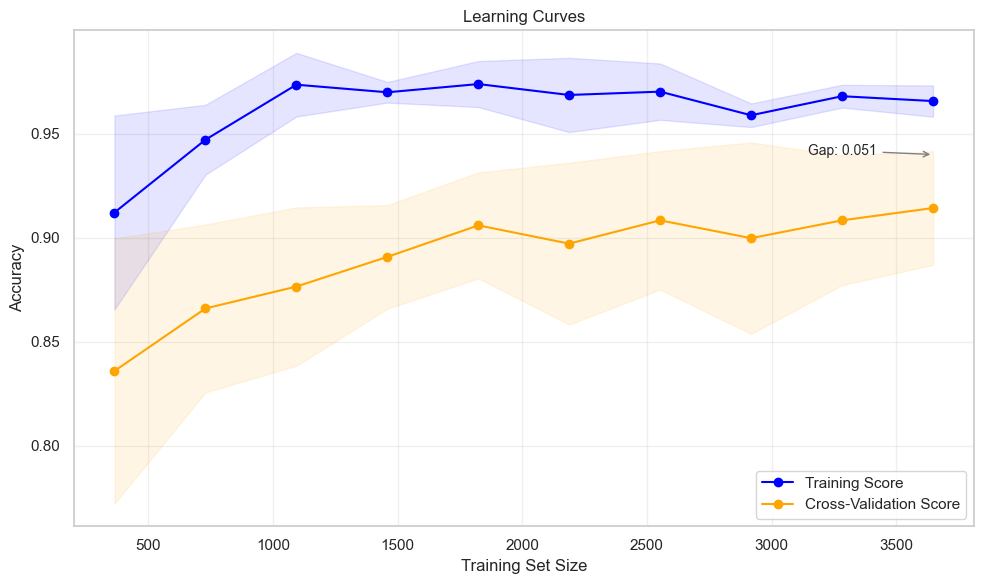


Final Training Accuracy: 0.9656 +/- 0.0075
Final CV Accuracy: 0.9143 +/- 0.0273
Generalization Gap: 0.0514


In [9]:
from sklearn.model_selection import learning_curve

print("Generating Learning Curves...")

# Use the final model for learning curves
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Add gap annotation
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap: {final_gap:.3f}', 
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            xytext=(train_sizes[-1] - 500, (train_mean[-1] + val_mean[-1])/2),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {train_mean[-1]:.4f} +/- {train_std[-1]:.4f}")
print(f"Final CV Accuracy: {val_mean[-1]:.4f} +/- {val_std[-1]:.4f}")
print(f"Generalization Gap: {final_gap:.4f}")

if final_gap > 0.05:
    print("Warning: Significant gap suggests possible overfitting.")
else:
    print("Model generalizes well (gap < 0.05).")

# 6. Final Model Evaluation

Performance metrics on the held-out test set using the optimized model.

Final Test Set Results
AUC:      0.9860
Accuracy: 0.9360

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       564
           1       0.93      0.95      0.94       576

    accuracy                           0.94      1140
   macro avg       0.94      0.94      0.94      1140
weighted avg       0.94      0.94      0.94      1140



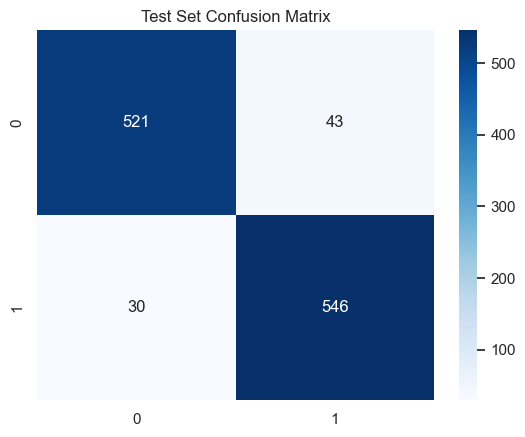

In [10]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("Final Test Set Results")
print(f"AUC:      {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.show()

# 7. Counterfactual Analysis

Interpret model decisions by finding the nearest counterfactual examples - similar sentences with opposite classifications.

COUNTERFACTUAL ANALYSIS

Original Sentence (Classified as BIASED):
   "Right-wingers lack compassion towards immigrants and refugees."

Closest Counterfactual (Classified as NEUTRAL):
   "The machinery operated consistently. Output quality was maintained."
   (Distance in feature space: 38.4752)


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


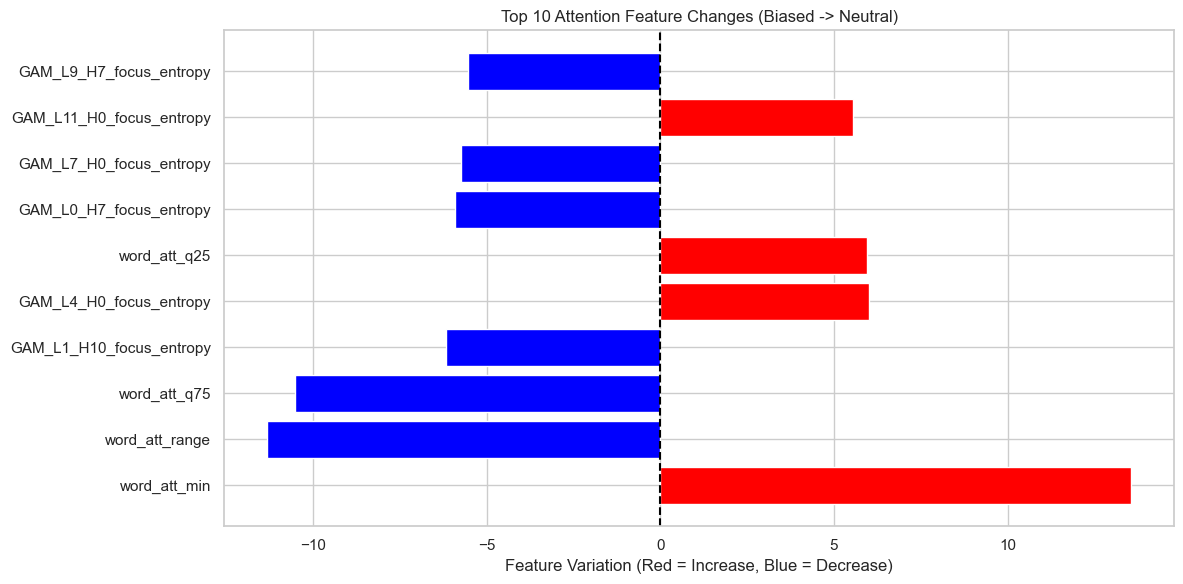

In [11]:
from scipy.spatial.distance import euclidean

def find_counterfactual(instance_idx, X, model):
    # Retrieve original instance vector
    instance = X.loc[instance_idx].values
    # Current prediction
    current_pred = model.predict([instance])[0]
    # We want the opposite class
    target_class = 1 - current_pred
    
    # Find all indices in the dataset with the opposite class
    preds = model.predict(X)
    candidate_indices = X.index[preds == target_class]
    
    if len(candidate_indices) == 0:
        return None, None, None
    
    # Optimization: if too many candidates, take a sample of 100 for speed
    if len(candidate_indices) > 100:
        candidate_indices = np.random.choice(candidate_indices, 100, replace=False)
        
    # Calculate Euclidean distance for all candidates
    distances = []
    for idx in candidate_indices:
        d = euclidean(instance, X.loc[idx].values)
        distances.append((idx, d))
    
    # Get the closest one
    distances.sort(key=lambda x: x[1])
    best_idx, min_dist = distances[0]
    return X.loc[best_idx].values, best_idx, min_dist

print("COUNTERFACTUAL ANALYSIS")

# Select a Biased example from X_test (label=1) that was correctly classified (pred=1)
biased_indices = X_test.index[(y_test == 1) & (final_model.predict(X_test) == 1)]

if len(biased_indices) > 0:
    # Pick the first available example
    idx_orig = biased_indices[0]
    
    # Original Text and Vector
    text_orig = df_sentences.loc[idx_orig, 'text']
    vec_orig = X_test.loc[idx_orig].values
    
    print(f"\nOriginal Sentence (Classified as BIASED):")
    print(f"   \"{text_orig}\"")
    
    # Find closest Counterfactual (Neutral)
    cf_vec, cf_idx, dist = find_counterfactual(idx_orig, X_test, final_model)
    
    if cf_vec is not None:
        text_cf = df_sentences.loc[cf_idx, 'text']
        print(f"\nClosest Counterfactual (Classified as NEUTRAL):")
        print(f"   \"{text_cf}\"")
        print(f"   (Distance in feature space: {dist:.4f})")
        
        # Visualize Feature Changes
        diff = cf_vec - vec_orig
        feat_names = X_test.columns
        
        # Get top 10 absolute changes
        top_ids = np.argsort(np.abs(diff))[::-1][:10]
        
        plot_feats = [feat_names[i] for i in top_ids]
        plot_vals = [diff[i] for i in top_ids]
        
        plt.figure(figsize=(12, 6))
        colors = ['red' if v > 0 else 'blue' for v in plot_vals]
        plt.barh(plot_feats, plot_vals, color=colors)
        plt.title(f"Top 10 Attention Feature Changes (Biased -> Neutral)")
        plt.xlabel("Feature Variation (Red = Increase, Blue = Decrease)")
        plt.axvline(0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()
    else:
        print("No opposite counterfactual found in this dataset.")
else:
    print("No correctly classified biased examples found in X_test to analyze.")

EXAMPLE 2: NEUTRAL Sentence -> What would make it Biased?

Original Sentence (Classified as NEUTRAL):
   "Literacy programs develop reading skills."

Closest Counterfactual (Classified as BIASED):
   "All Muslims support terrorism."
   (Distance in feature space: 42.8245)


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


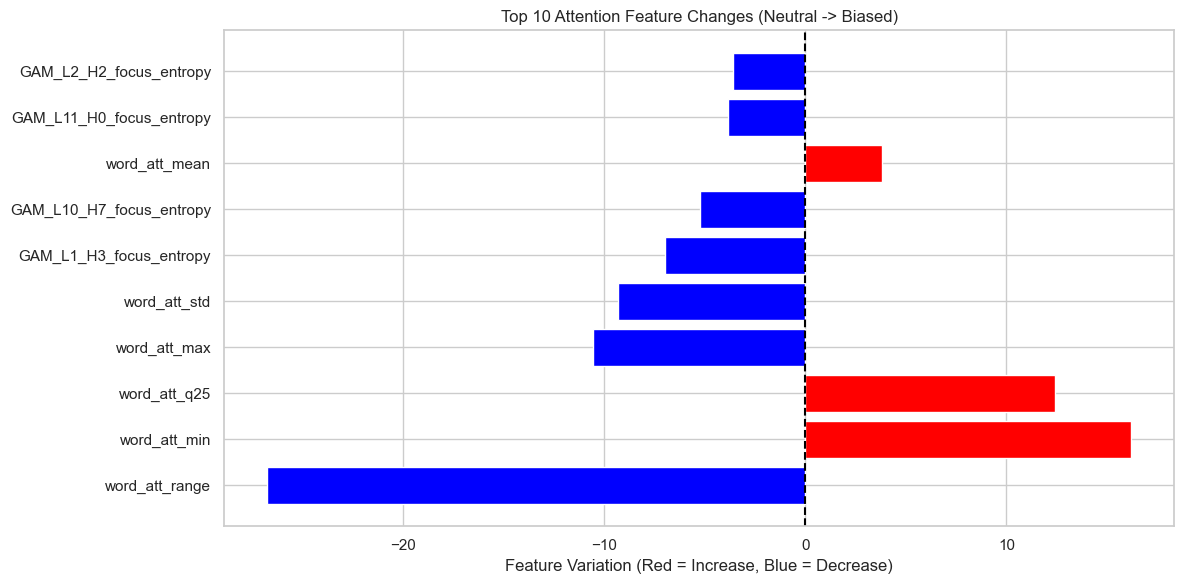

In [12]:

print("EXAMPLE 2: NEUTRAL Sentence -> What would make it Biased?")

# Select a Neutral example from X_test (label=0) that was correctly classified (pred=0)
neutral_indices = X_test.index[(y_test == 0) & (final_model.predict(X_test) == 0)]

if len(neutral_indices) > 0:
    # Pick the first available example
    idx_orig = neutral_indices[0]
    
    # Original Text and Vector
    text_orig = df_sentences.loc[idx_orig, 'text']
    vec_orig = X_test.loc[idx_orig].values
    
    print(f"\nOriginal Sentence (Classified as NEUTRAL):")
    print(f"   \"{text_orig}\"")
    
    # Find closest Counterfactual (Biased)
    cf_vec, cf_idx, dist = find_counterfactual(idx_orig, X_test, final_model)
    
    if cf_vec is not None:
        text_cf = df_sentences.loc[cf_idx, 'text']
        print(f"\nClosest Counterfactual (Classified as BIASED):")
        print(f"   \"{text_cf}\"")
        print(f"   (Distance in feature space: {dist:.4f})")
        
        # Visualize Feature Changes
        diff = cf_vec - vec_orig
        feat_names = X_test.columns
        
        # Get top 10 absolute changes
        top_ids = np.argsort(np.abs(diff))[::-1][:10]
        
        plot_feats = [feat_names[i] for i in top_ids]
        plot_vals = [diff[i] for i in top_ids]
        
        plt.figure(figsize=(12, 6))
        colors = ['red' if v > 0 else 'blue' for v in plot_vals]
        plt.barh(plot_feats, plot_vals, color=colors)
        plt.title(f"Top 10 Attention Feature Changes (Neutral -> Biased)")
        plt.xlabel("Feature Variation (Red = Increase, Blue = Decrease)")
        plt.axvline(0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()
    else:
        print("No biased counterfactual found in this dataset.")
else:
    print("No correctly classified neutral examples found in X_test to analyze.")

# 8. Feature Importance Analysis

Model interpretation using SHAP values and permutation importance to identify which attention features contribute most to bias detection.

Features after VT: 414 / 3238
SHAP (Tree)
TreeExplainer failed: Model type not yet supported by TreeExplainer: <class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>. Using KernelExplainer.
SHAP (Kernel)


  0%|          | 0/1375 [00:00<?, ?it/s]

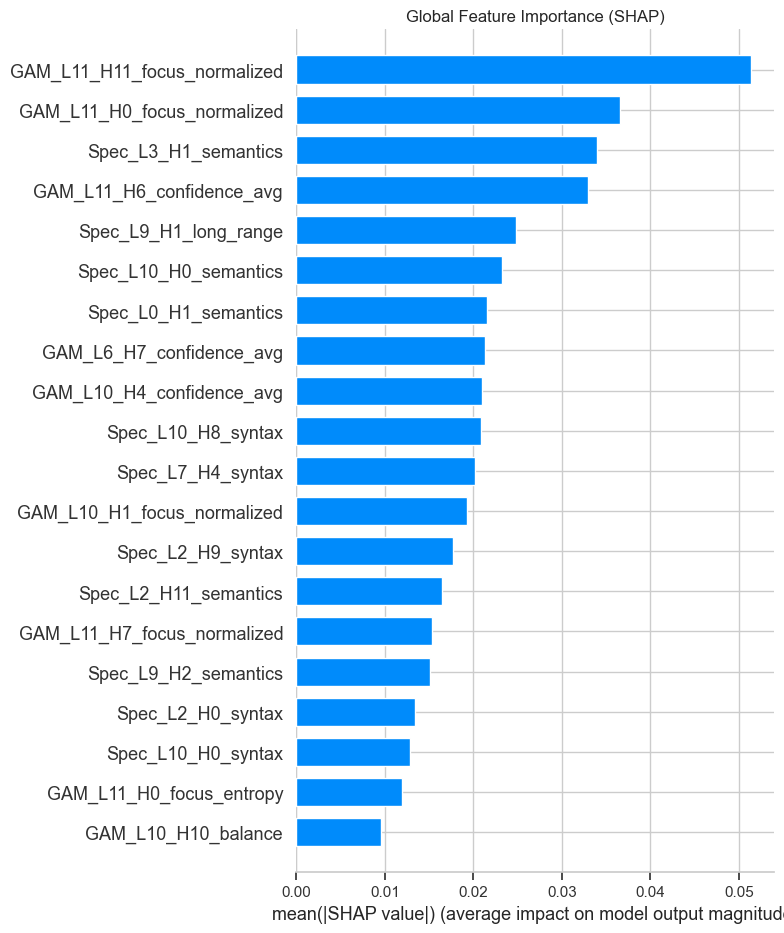

In [13]:
import shap
import gc

# Clear memory
gc.collect()

# Extract pipeline steps
vt_step = final_model.named_steps['vt']
model_step = final_model.named_steps['m']
scaler_step = final_model.named_steps['s']
fs_step = final_model.named_steps.get('fs', None)  # SelectKBest (may not exist)

# Get selected feature names after VarianceThreshold
vt_mask = vt_step.get_support()
selected_features = X_train.columns[vt_mask]
print(f"Features after VT: {vt_mask.sum()} / {len(vt_mask)}")

# Apply SelectKBest mask if present
if fs_step is not None:
    fs_mask = fs_step.get_support()
    selected_features = selected_features[fs_mask]
    print(f"Features after SelectKBest: {fs_mask.sum()} / {len(fs_mask)}")

# Transform test data through VT (and SelectKBest if present) then Scaler
X_test_vt = vt_step.transform(X_test)
if fs_step is not None:
    X_test_vt = fs_step.transform(X_test_vt)
X_test_scaled = scaler_step.transform(X_test_vt)
X_test_df = pd.DataFrame(X_test_scaled, columns=selected_features, index=X_test.index)

X_shap = X_test_df

try:
    print("SHAP (Tree)")
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list): shap_values = shap_values[1]

except Exception as e:
    print(f"TreeExplainer failed: {e}. Using KernelExplainer.")

    X_train_vt = vt_step.transform(X_train)
    if fs_step is not None:
        X_train_vt = fs_step.transform(X_train_vt)
    background = np.median(scaler_step.transform(X_train_vt), axis=0).reshape(1, -1)

    f = lambda x: model_step.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(f, background)

    print("SHAP (Kernel)")
    shap_values = explainer.shap_values(X_shap, nsamples=2000)

# Plot Results
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()


Extracting feature importance from: MLPClassifier
Features used by model: 414
  Using first layer weights (MLP)

Top 50 most important features
rank   feature                                                 importance      direction    method
----------------------------------------------------------------------------------------------------
1      GAM_L11_H0_focus_normalized                                 0.186345   n/a          mlp_weights
2      GAM_L11_H11_focus_normalized                                0.179592   n/a          mlp_weights
3      Spec_L7_H5_semantics                                        0.152277   n/a          mlp_weights
4      Spec_L3_H1_semantics                                        0.150160   n/a          mlp_weights
5      GAM_L10_H1_focus_normalized                                 0.131472   n/a          mlp_weights
6      Spec_L10_H0_punct                                           0.128948   n/a          mlp_weights
7      Spec_L0_H1_semantics           

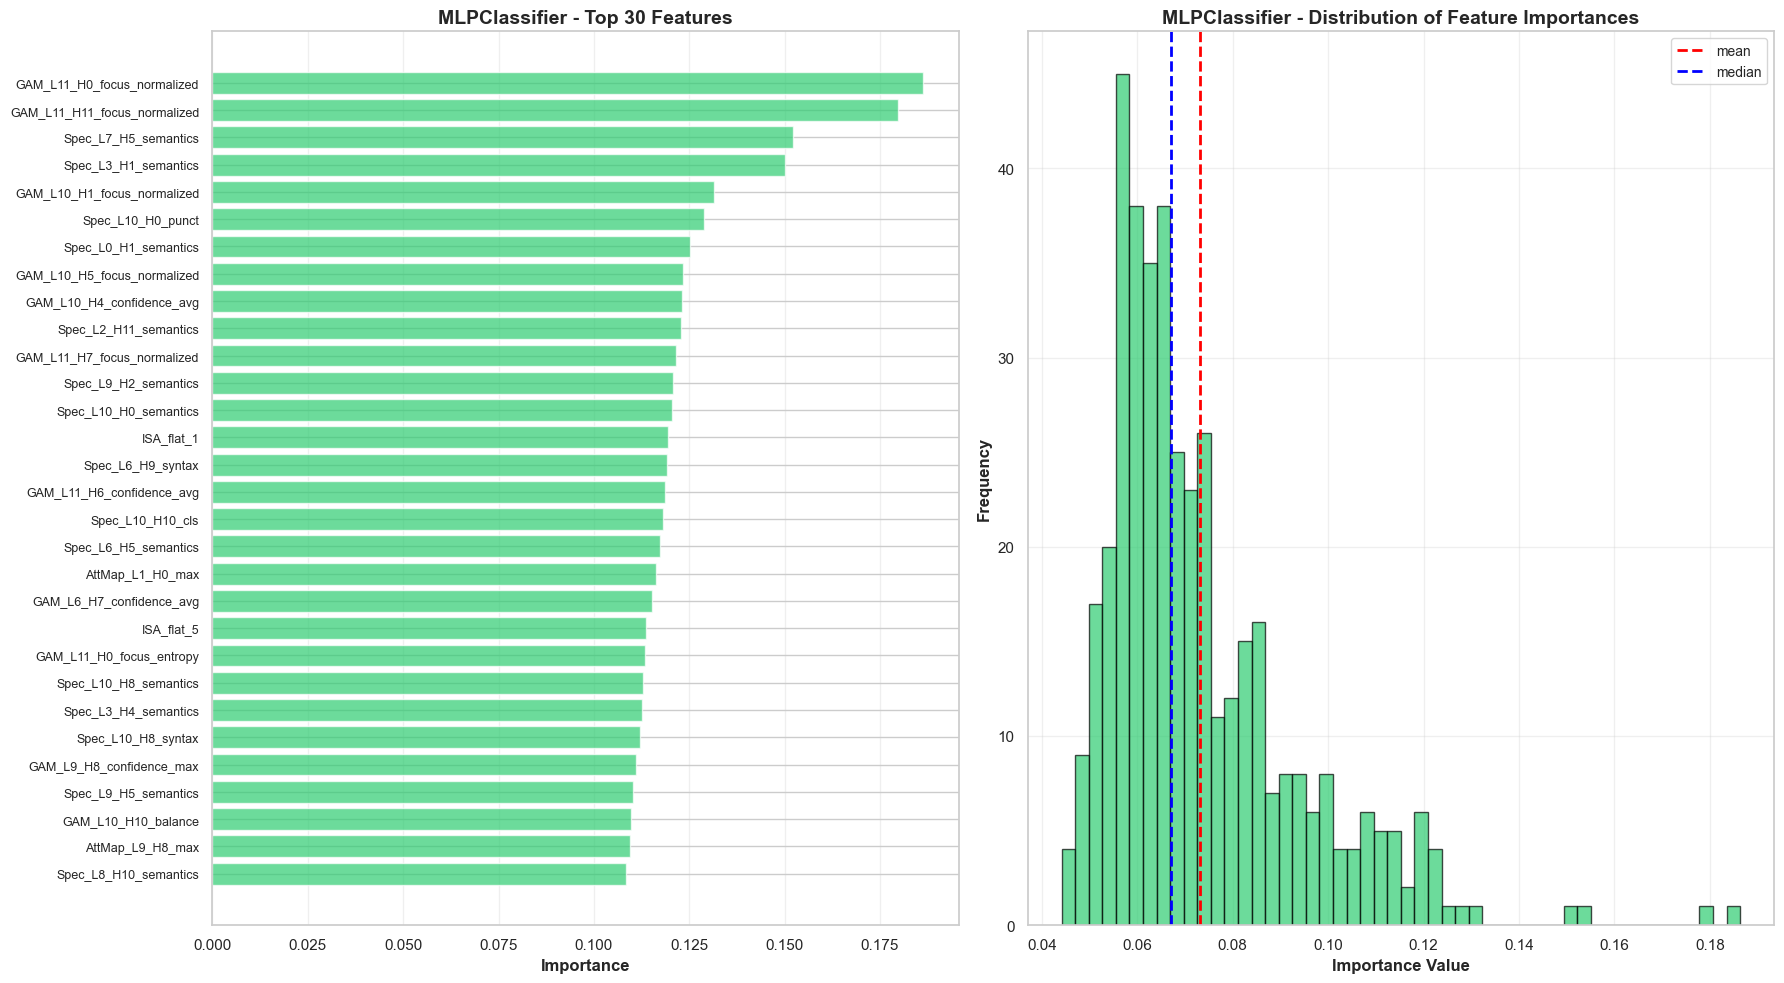


Feature importance saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\feature_importance_mlpclassifier.csv

Feature Type Breakdown (top 100)
  Spec (head specialization)           51 features ( 51.0%)
  GAM (global attention)               36 features ( 36.0%)
  AttMap (raw attention)               10 features ( 10.0%)
  ISA (inter-sentence)                  3 features (  3.0%)

Feature importance analysis complete


9

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

def extract_feature_importance(pipeline_model, X_test, y_test=None):
    """
    Extract feature importance from sklearn pipeline.
    Handles pipelines with VarianceThreshold and SelectKBest steps.
    """
    gc.collect()

    model_step = pipeline_model.named_steps['m']

    # Get feature names after VT (if present)
    if 'vt' in pipeline_model.named_steps:
        vt_step = pipeline_model.named_steps['vt']
        vt_mask = vt_step.get_support()
        feature_names = X_test.columns[vt_mask].tolist()
    else:
        feature_names = X_test.columns.tolist()

    # Apply SelectKBest mask if present
    if 'fs' in pipeline_model.named_steps:
        fs_step = pipeline_model.named_steps['fs']
        fs_mask = fs_step.get_support()
        feature_names = [f for f, m in zip(feature_names, fs_mask) if m]

    model_type = type(model_step).__name__
    print(f"Extracting feature importance from: {model_type}")
    print(f"Features used by model: {len(feature_names)}")

    # Coefficients (logistic regression, linear SVC, etc.)
    if hasattr(model_step, 'coef_'):
        print("  Using model coefficients")
        coef = model_step.coef_[0] if model_step.coef_.ndim > 1 else model_step.coef_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': np.abs(coef),
            'Raw_Coefficient': coef,
            'Direction': ['positive' if c > 0 else 'negative' for c in coef]
        })
        importance_df['Method'] = 'coefficients'

    # Feature importances (random forest, xgboost, etc.)
    elif hasattr(model_step, 'feature_importances_'):
        print("  Using feature_importances (gini/gain)")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model_step.feature_importances_,
            'Raw_Coefficient': model_step.feature_importances_,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'impurity'

    # MLP weights from first layer
    elif hasattr(model_step, 'coefs_') and len(model_step.coefs_) > 0:
        print("  Using first layer weights (MLP)")
        first_layer_weights = model_step.coefs_[0]
        importance = np.mean(np.abs(first_layer_weights), axis=1)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'mlp_weights'

    else:
        print("  No direct importance method available, using uniform")
        importance = np.ones(len(feature_names)) / len(feature_names)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'uniform_fallback'

    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    gc.collect()
    return importance_df, model_type


# Extract importance from best model
feature_importance_df, model_name_imp = extract_feature_importance(
    pipeline_model=final_model,
    X_test=X_test,
    y_test=y_test
)

# Display top 50
print("\nTop 50 most important features")
print(f"{'rank':<6} {'feature':<55} {'importance':<15} {'direction':<12} {'method'}")
print("-"*100)

for idx, row in feature_importance_df.head(50).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<55} {row['Importance']:>12.6f}   {row['Direction']:<12} {row['Method']}")

# Summary statistics
print("\nSummary Statistics")
print(f"Model type:         {model_name_imp}")
print(f"Importance method:  {feature_importance_df['Method'].iloc[0]}")
print(f"Total features:     {len(feature_importance_df)}")
print(f"Max importance:     {feature_importance_df['Importance'].max():.6f}")
print(f"Min importance:     {feature_importance_df['Importance'].min():.6f}")
print(f"Mean importance:    {feature_importance_df['Importance'].mean():.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_30 = feature_importance_df.head(30)

if 'positive' in str(feature_importance_df['Direction'].iloc[0]):
    colors = ['#e74c3c' if 'positive' in d else '#3498db' for d in top_30['Direction']]
    title_suffix = '\n(red = positive, blue = negative)'
else:
    colors = '#2ecc71'
    title_suffix = ''

axes[0].barh(range(len(top_30)), top_30['Importance'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['Feature'], fontsize=9)
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title(f'{model_name_imp} - Top 30 Features{title_suffix}', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].hist(feature_importance_df['Importance'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1].axvline(x=feature_importance_df['Importance'].mean(), color='red', linestyle='--', linewidth=2, label='mean')
axes[1].axvline(x=feature_importance_df['Importance'].median(), color='blue', linestyle='--', linewidth=2, label='median')
axes[1].set_xlabel('Importance Value', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'{model_name_imp} - Distribution of Feature Importances', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
output_path = os.path.join(root_dir, 'attention_app', 'bias', f'feature_importance_{model_name_imp.lower()}.csv')
feature_importance_df.to_csv(output_path, index=False)
print(f"\nFeature importance saved to: {output_path}")

# Feature type breakdown
print("\nFeature Type Breakdown (top 100)")
top_100_features = feature_importance_df.head(100)['Feature']

feature_types = {
    'GAM (global attention)': 0,
    'Spec (head specialization)': 0,
    'ISA (inter-sentence)': 0,
    'Tree (dependency)': 0,
    'AttMap (raw attention)': 0,
    'Word (word attention stats)': 0,
    'Other': 0
}

for feat in top_100_features:
    if feat.startswith('GAM'):
        feature_types['GAM (global attention)'] += 1
    elif feat.startswith('Spec'):
        feature_types['Spec (head specialization)'] += 1
    elif feat.startswith('ISA'):
        feature_types['ISA (inter-sentence)'] += 1
    elif feat.startswith('Tree'):
        feature_types['Tree (dependency)'] += 1
    elif feat.startswith('AttMap'):
        feature_types['AttMap (raw attention)'] += 1
    elif feat.startswith('word_att'):
        feature_types['Word (word attention stats)'] += 1
    else:
        feature_types['Other'] += 1

for feat_type, count in sorted(feature_types.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        pct = (count / 100) * 100
        print(f"  {feat_type:<35} {count:>3} features ({pct:>5.1f}%)")

print("\nFeature importance analysis complete")
gc.collect()


cumulative importance analysis

features needed for cumulative importance:
  80%: 303 features
  90%: 355 features
  95%: 383 features
  rfecv optimal: 195 features (57.29% cumulative)


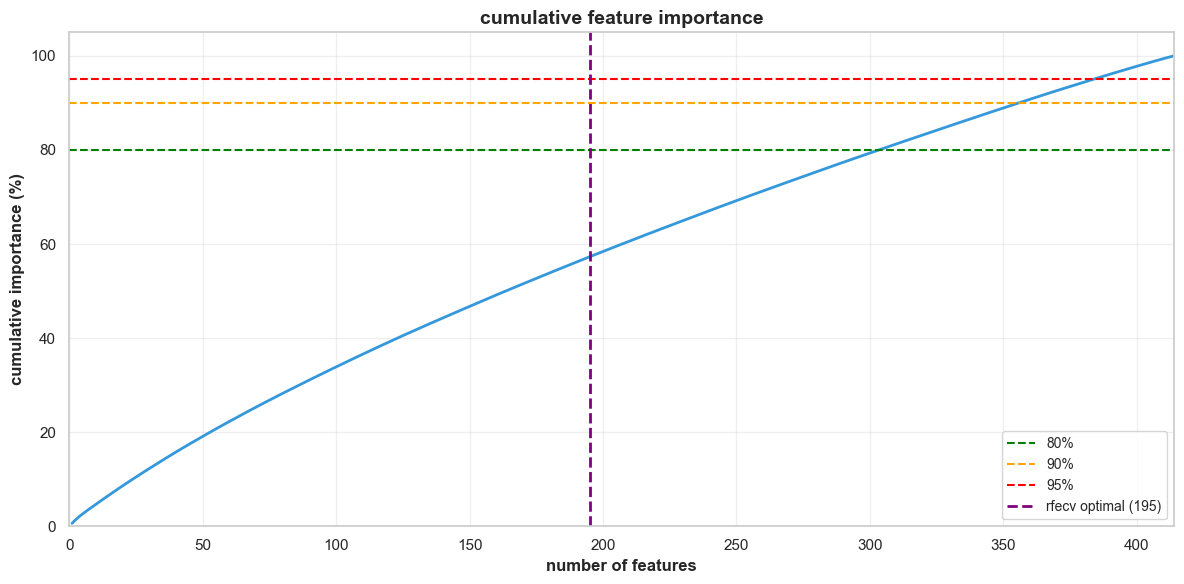

In [15]:
# cumulative importance analysis
print("cumulative importance analysis")

# calculate cumulative importance
feature_importance_sorted = feature_importance_df.sort_values('Importance', ascending=False)
total_importance = feature_importance_sorted['Importance'].sum()
feature_importance_sorted['Cumulative_Importance'] = (
    feature_importance_sorted['Importance'].cumsum() / total_importance * 100
)

# find how many features for 80%, 90%, 95%
n_80 = (feature_importance_sorted['Cumulative_Importance'] <= 80).sum()
n_90 = (feature_importance_sorted['Cumulative_Importance'] <= 90).sum()
n_95 = (feature_importance_sorted['Cumulative_Importance'] <= 95).sum()

print(f"\nfeatures needed for cumulative importance:")
print(f"  80%: {n_80} features")
print(f"  90%: {n_90} features")
print(f"  95%: {n_95} features")
print(f"  rfecv optimal: 195 features ({feature_importance_sorted.iloc[194]['Cumulative_Importance']:.2f}% cumulative)")

# visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(feature_importance_sorted) + 1), 
        feature_importance_sorted['Cumulative_Importance'].values,
        linewidth=2, color='#3498db')

ax.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='80%')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90%')
ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95%')
ax.axvline(x=195, color='purple', linestyle='--', linewidth=2, label='rfecv optimal (195)')

ax.set_xlabel('number of features', fontsize=12, fontweight='bold')
ax.set_ylabel('cumulative importance (%)', fontsize=12, fontweight='bold')
ax.set_title('cumulative feature importance', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, len(feature_importance_sorted))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 8.1 Permutation Feature Importance

Measure the decrease in model accuracy when a single feature's values are randomly shuffled, breaking the relationship between the feature and the target. Computed on the held-out test set.

Calculating Permutation Importance...


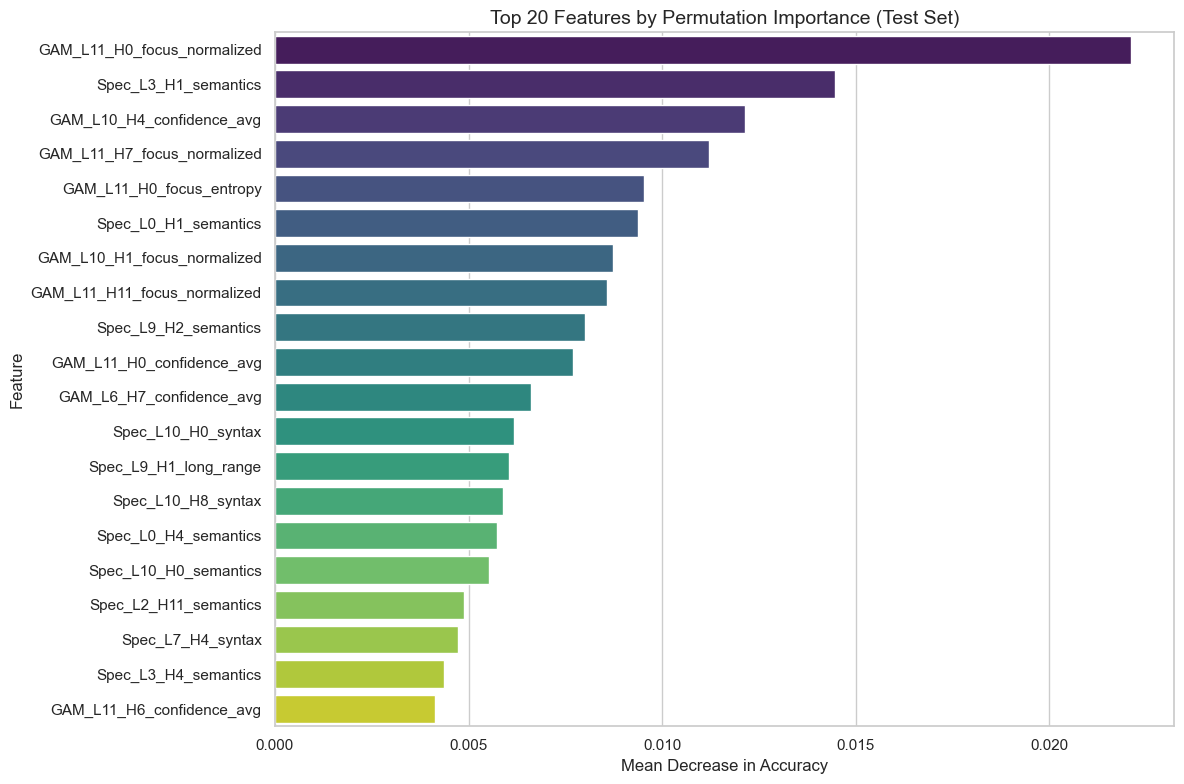

Top 5 Most Important Features:
                          Feature  Importance
1329  GAM_L11_H0_focus_normalized    0.022109
1831         Spec_L3_H1_semantics    0.014473
1241    GAM_L10_H4_confidence_avg    0.012145
1399  GAM_L11_H7_focus_normalized    0.011200
1322     GAM_L11_H0_focus_entropy    0.009527


In [16]:
from sklearn.inspection import permutation_importance

print("Calculating Permutation Importance...")

# Run permutation importance on the Test set
# n_repeats=10 provides a stable estimate
perm_importance = permutation_importance(
    final_model, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=1
)

# Create DataFrame for visualization
perm_features_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
})

# Sort and get top 20
top_perm_features = perm_features_df.sort_values('Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_perm_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 20 Features by Permutation Importance (Test Set)', fontsize=14)
plt.xlabel('Mean Decrease in Accuracy', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(top_perm_features[['Feature', 'Importance']].head(5))

## 8.2 Feature Stability Analysis

Assess the stability of top features across multiple permutation runs to ensure they are not artifacts of a specific random seed.

Analyzing Feature Stability...


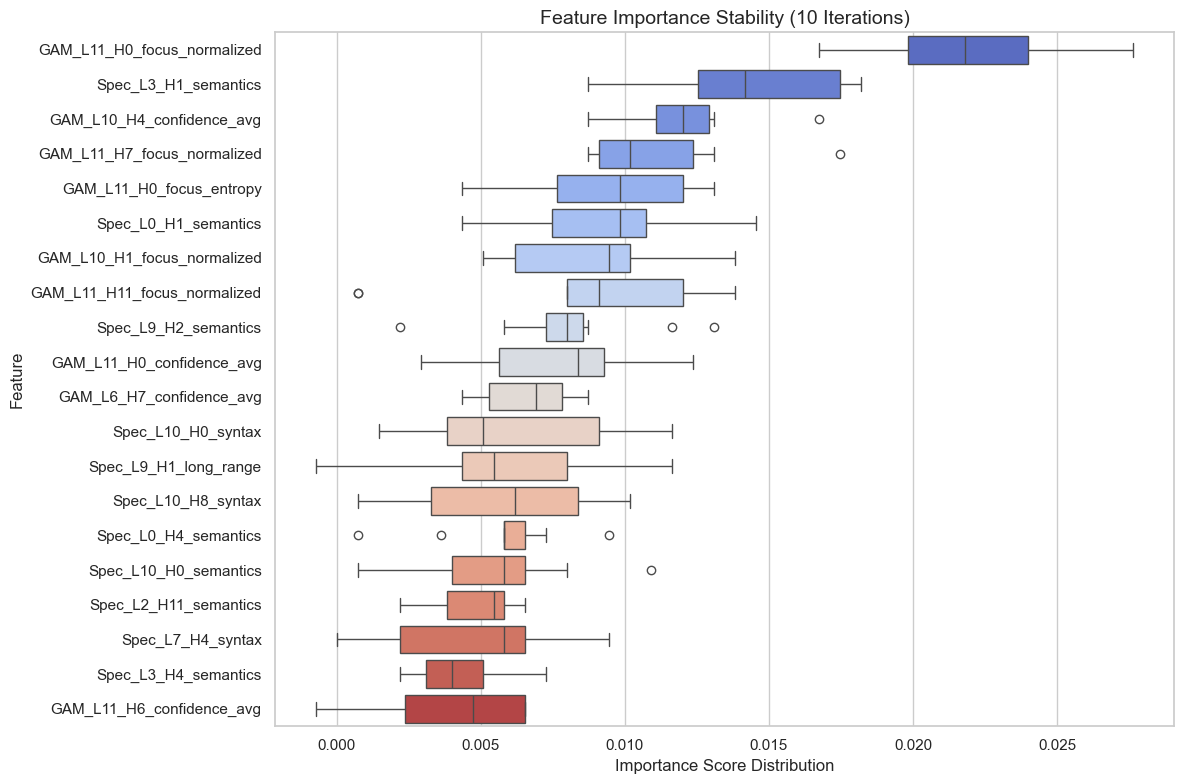

In [17]:
print("Analyzing Feature Stability...")

# We already have the raw importance scores from the previous step (perm_importance.importances)
# It has shape (n_features, n_repeats)

# Get indices of top 20 features
top_indices = perm_importance.importances_mean.argsort()[::-1][:20]

# Prepare data for boxplot
stability_data = []
for idx in top_indices:
    feature_name = X_test.columns[idx]
    scores = perm_importance.importances[idx]
    for score in scores:
        stability_data.append({
            'Feature': feature_name,
            'Score': score
        })

stability_df = pd.DataFrame(stability_data)

# Plot Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=stability_df, x='Score', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance Stability (10 Iterations)', fontsize=14)
plt.xlabel('Importance Score Distribution', fontsize=12)
plt.tight_layout()
plt.show()

## 8.3 Consensus Feature Ranking

Average rankings from multiple feature importance methods to identify the most robustly important features.

Running Consensus Feature Selection...
Features ranked by importance: 3238
Processing SHAP values...
Shape of raw SHAP values: (1375, 414)
Shape of mean absolute SHAP: (414,)
Number of features in X_shap: 414
Features ranked by SHAP: 414

COMPLETE CONSENSUS RANKING
Top 20 features by consensus:
                     Feature  Consensus_Rank  Importance_Rank  SHAP_Rank
 GAM_L11_H0_focus_normalized             1.5              1.0        2.0
        Spec_L3_H1_semantics             2.5              2.0        3.0
GAM_L11_H11_focus_normalized             4.5              8.0        1.0
   GAM_L10_H4_confidence_avg             6.0              3.0        9.0
        Spec_L0_H1_semantics             6.5              6.0        7.0
       Spec_L9_H1_long_range             9.0             13.0        5.0
 GAM_L11_H7_focus_normalized             9.5              4.0       15.0
 GAM_L10_H1_focus_normalized             9.5              7.0       12.0
    GAM_L6_H7_confidence_avg             9.5   

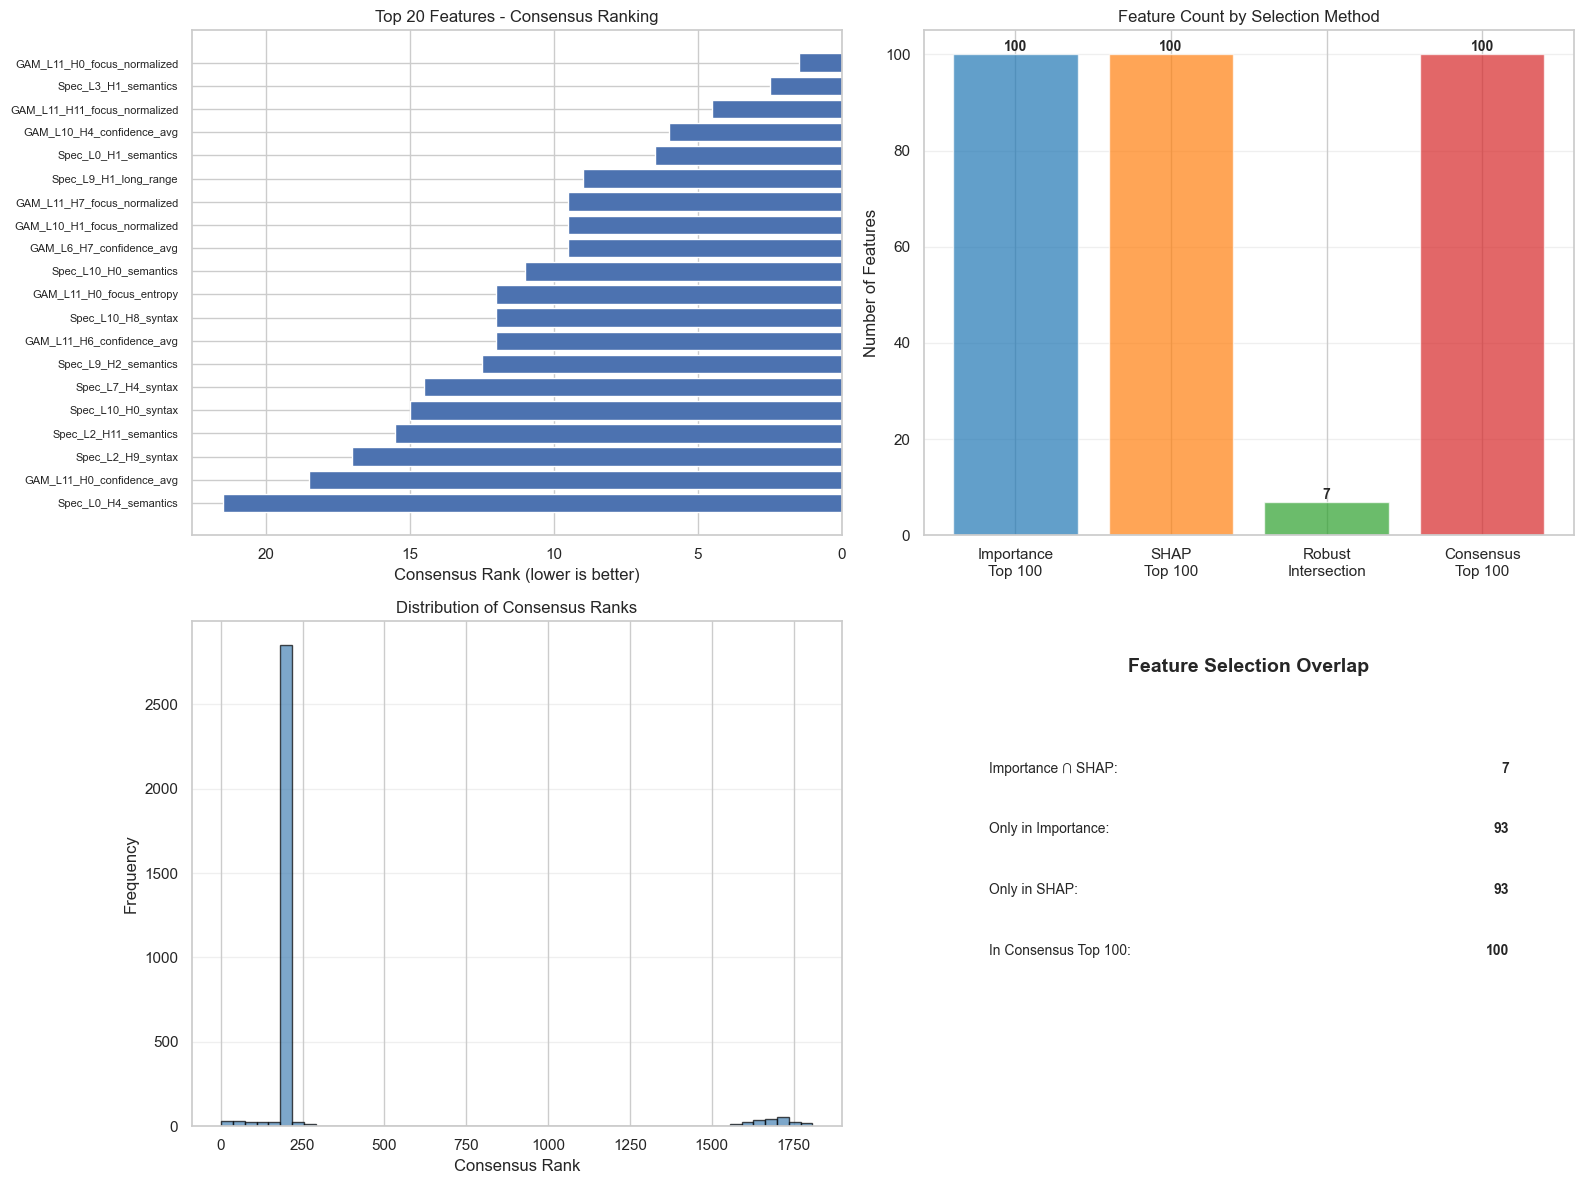

In [18]:
print("Running Consensus Feature Selection...")

# Use variables from previous SHAP cell
feature_importance_df = perm_features_df

# RANKING BY FEATURE IMPORTANCE
importance_scores = dict(zip(feature_importance_df['Feature'], 
                             feature_importance_df['Importance']))
importance_rank = feature_importance_df.set_index('Feature')['Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by importance: {len(importance_rank)}")


# RANKING BY SHAP
print('Processing SHAP values...')
vals = shap_values

# If it's an Explanation object (new SHAP API)
if hasattr(vals, 'values'):
    vals = vals.values

# Check for list (multi-class) and select positive class if so
if isinstance(vals, list):
    print(f'SHAP values is a list (multi-class). Using class 1 (positive) importance.')
    vals = vals[1]

# Ensure vals is numpy array
vals = np.array(vals)
print(f'Shape of raw SHAP values: {vals.shape}')

# Handle 3D case (samples, features, classes)
if vals.ndim == 3:
    if vals.shape[-1] == 2:
        print('3D SHAP values (N, M, C) detected. Selecting class 1.')
        vals = vals[:, :, 1]
    elif vals.shape[0] == 2:
        print('3D SHAP values (C, N, M) detected. Selecting class 1.')
        vals = vals[1]
    else:
        print('3D SHAP values with unknown structure. Defaulting to [:, :, 1].')
        vals = vals[:, :, 1]

mean_abs_shap = np.mean(np.abs(vals), axis=0)
print(f'Shape of mean absolute SHAP: {mean_abs_shap.shape}')
print(f'Number of features in X_shap: {len(X_shap.columns)}')

# Safety check
if len(mean_abs_shap) != len(X_shap.columns):
    print(f'WARNING: Shape mismatch! {len(mean_abs_shap)} vs {len(X_shap.columns)}')
    if len(mean_abs_shap) == 2 * len(X_shap.columns):
         print('Attempting to fix double-length array. Taking first half.')
         mean_abs_shap = mean_abs_shap[:len(X_shap.columns)]

shap_importance_df = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP_Importance': mean_abs_shap
}).sort_values('SHAP_Importance', ascending=False)

shap_rank = shap_importance_df.set_index('Feature')['SHAP_Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by SHAP: {len(shap_rank)}")


# CONSENSUS RANKING (Average of 2 rankings)
all_features = set(importance_rank.keys()) | set(shap_rank.keys())

consensus_scores = {}
for feat in all_features:
    ranks = []
    if feat in importance_rank:
        ranks.append(importance_rank[feat])
    if feat in shap_rank:
        ranks.append(shap_rank[feat])
    consensus_scores[feat] = np.mean(ranks) if ranks else float('inf')

consensus_df = pd.DataFrame([
    {'Feature': feat, 'Consensus_Rank': score}
    for feat, score in consensus_scores.items()
]).sort_values('Consensus_Rank')

consensus_df['Importance_Rank'] = consensus_df['Feature'].map(importance_rank)
consensus_df['SHAP_Rank'] = consensus_df['Feature'].map(shap_rank)

print(f"\nCOMPLETE CONSENSUS RANKING")
print(f"Top 20 features by consensus:")
print(consensus_df.head(20).to_string(index=False))


# EXTRACT TOP FEATURES BY EACH METHOD
top_100_importance = feature_importance_df.head(100)['Feature'].tolist()
top_100_shap = shap_importance_df.head(100)['Feature'].tolist()
top_100_consensus = consensus_df.head(100)['Feature'].tolist()
robust_features = [f for f in top_100_importance if f in top_100_shap]

print(f"\nMETHODS SUMMARY")
print(f"Method 1 - Top 100 by Importance:    {len(top_100_importance)}")
print(f"Method 2 - Top 100 by SHAP:          {len(top_100_shap)}")
print(f"Method 3 - Robust (Intersection):    {len(robust_features)}")
print(f"Method 4 - Top 100 by Consensus:     {len(top_100_consensus)}")


# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
top_20_consensus = consensus_df.head(20)
ax1.barh(range(len(top_20_consensus)), top_20_consensus['Consensus_Rank'])
ax1.set_yticks(range(len(top_20_consensus)))
ax1.set_yticklabels(top_20_consensus['Feature'], fontsize=8)
ax1.set_xlabel('Consensus Rank (lower is better)')
ax1.set_title('Top 20 Features - Consensus Ranking')
ax1.invert_yaxis()
ax1.invert_xaxis()

ax2 = axes[0, 1]
methods = ['Importance\nTop 100', 'SHAP\nTop 100', 'Robust\nIntersection', 'Consensus\nTop 100']
counts = [len(top_100_importance), len(top_100_shap), len(robust_features), len(top_100_consensus)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax2.bar(methods, counts, color=colors, alpha=0.7)
ax2.set_ylabel('Number of Features')
ax2.set_title('Feature Count by Selection Method')
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[1, 0]
ax3.hist(consensus_df['Consensus_Rank'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Consensus Rank')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Consensus Ranks')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
ax4.text(0.5, 0.9, 'Feature Selection Overlap', ha='center', fontsize=14, fontweight='bold')
overlaps = [
    ('Importance ∩ SHAP', len(robust_features)),
    ('Only in Importance', len([f for f in top_100_importance if f not in top_100_shap])),
    ('Only in SHAP', len([f for f in top_100_shap if f not in top_100_importance])),
    ('In Consensus Top 100', len(top_100_consensus)),
]
y_pos = 0.7
for label, count in overlaps:
    ax4.text(0.1, y_pos, f'{label}:', fontsize=10)
    ax4.text(0.9, y_pos, f'{count}', fontsize=10, fontweight='bold', ha='right')
    y_pos -= 0.12
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

## 8.5 Performance vs Number of Features (K)

Evaluate model performance across different numbers of top features to find the smallest K within 1% of the peak.
Features are selected using ANOVA F-test (SelectKBest) inside the pipeline, with group-aware cross-validation.

Evaluating Performance vs Number of Features (K)...
  K=  10: Acc=0.8019 | AUC=0.8572 | F1=0.8174
  K=  20: Acc=0.8208 | AUC=0.8812 | F1=0.8357
  K=  50: Acc=0.8705 | AUC=0.9440 | F1=0.8732
  K=  75: Acc=0.8885 | AUC=0.9590 | F1=0.8903
  K= 100: Acc=0.8914 | AUC=0.9584 | F1=0.8914
  K= 150: Acc=0.8965 | AUC=0.9588 | F1=0.8966
  K= 200: Acc=0.9125 | AUC=0.9701 | F1=0.9130
  K= 300: Acc=0.9154 | AUC=0.9741 | F1=0.9158
  K= 414: Acc=0.9222 | AUC=0.9766 | F1=0.9220

Best AUC: 0.9766
1% threshold: 0.9668
Optimal K (smallest within 1% of best): 200


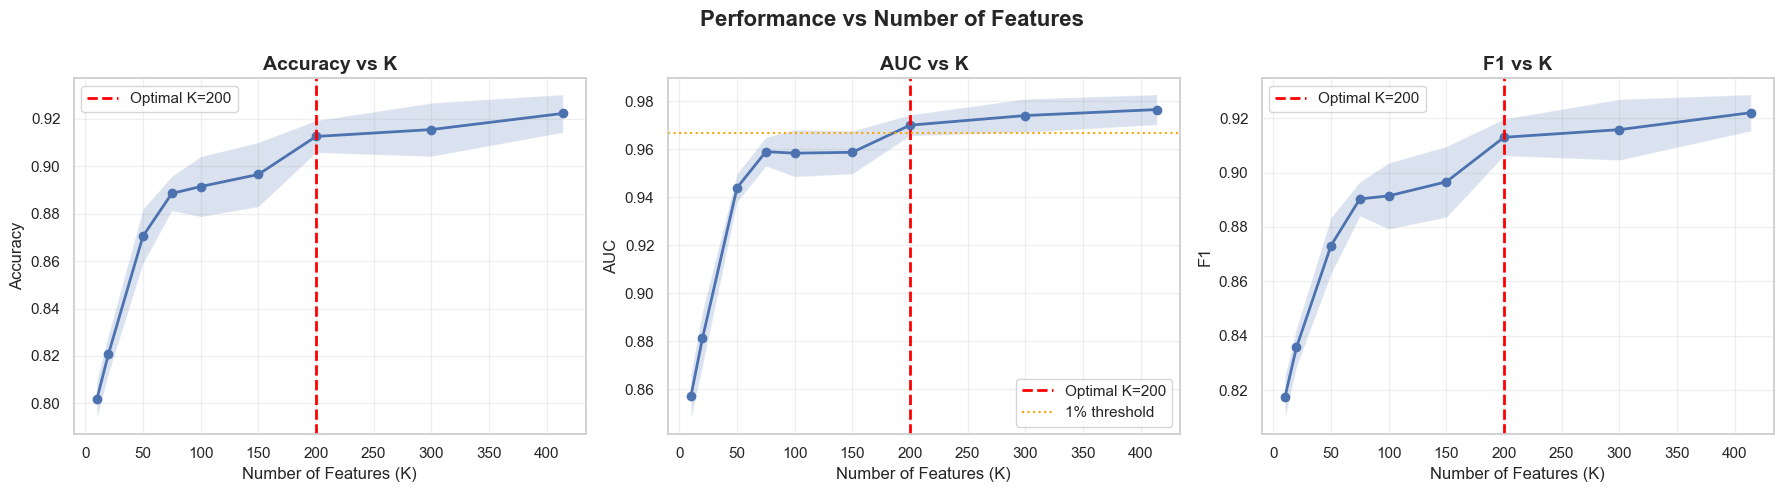


Retraining final model with SelectKBest(k=200)...
Refined Model (K=200) Test Performance:
  Accuracy: 0.9389
  AUC:      0.9875
  Features used: 200 (down from 414 after VT)


In [19]:
# Performance vs K: find optimal number of features
print("Evaluating Performance vs Number of Features (K)...")

# Use the best model type from earlier comparison
best_model_cls = models[best_model_name]

# K values to evaluate
n_features_after_vt = final_model.named_steps['vt'].get_support().sum()
k_values = sorted(set([10, 20, 50, 75, 100, 150, 200, 300, 500,
                        min(750, n_features_after_vt),
                        n_features_after_vt]))
k_values = [k for k in k_values if k <= n_features_after_vt]

cv_k = StratifiedGroupKFold(n_splits=5)
k_results = []

for k in k_values:
    # Pipeline: VT -> SelectKBest(k) -> Scaler -> Model
    if k == n_features_after_vt:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])
    else:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('fs', SelectKBest(f_classif, k=k)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])

    scores = cross_validate(
        pipe_k, X_train, y_train, cv=cv_k,
        scoring=['accuracy', 'roc_auc', 'f1'],
        groups=groups_train
    )

    k_results.append({
        'K': k,
        'Accuracy': scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'AUC': scores['test_roc_auc'].mean(),
        'AUC_std': scores['test_roc_auc'].std(),
        'F1': scores['test_f1'].mean(),
        'F1_std': scores['test_f1'].std()
    })
    print(f"  K={k:>4}: Acc={scores['test_accuracy'].mean():.4f} | "
          f"AUC={scores['test_roc_auc'].mean():.4f} | "
          f"F1={scores['test_f1'].mean():.4f}")

df_k = pd.DataFrame(k_results)

# Find optimal K: smallest K within 1% of the best AUC
best_auc_k = df_k['AUC'].max()
threshold_1pct = best_auc_k * 0.99
optimal_k = df_k.loc[df_k['AUC'] >= threshold_1pct, 'K'].min()

print(f"\nBest AUC: {best_auc_k:.4f}")
print(f"1% threshold: {threshold_1pct:.4f}")
print(f"Optimal K (smallest within 1% of best): {optimal_k}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['Accuracy', 'AUC', 'F1']):
    ax.plot(df_k['K'], df_k[metric], 'o-', linewidth=2, markersize=6)
    ax.fill_between(df_k['K'],
                     df_k[metric] - df_k[f'{metric}_std'],
                     df_k[metric] + df_k[f'{metric}_std'],
                     alpha=0.2)
    ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
               label=f'Optimal K={optimal_k}')
    if metric == 'AUC':
        ax.axhline(y=threshold_1pct, color='orange', linestyle=':',
                    label='1% threshold')
    ax.set_xlabel('Number of Features (K)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} vs K', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Performance vs Number of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Retrain final model with SelectKBest(k=optimal_k) ───
print(f"\nRetraining final model with SelectKBest(k={optimal_k})...")

# Get the best hyperparameters from the tuning step
best_params = search.best_params_
# Extract only model params (strip the m__ prefix)
model_params = {k.replace('m__', ''): v for k, v in best_params.items() if k.startswith('m__')}

# Build the refined pipeline: VT -> SelectKBest -> Scaler -> tuned Model
refined_model = clone(best_model_cls).set_params(**model_params)
final_model = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('fs', SelectKBest(f_classif, k=min(optimal_k, n_features_after_vt))),
    ('s', StandardScaler()),
    ('m', refined_model)
])
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_refined = final_model.predict(X_test)
y_proba_refined = final_model.predict_proba(X_test)[:, 1]

print(f"Refined Model (K={optimal_k}) Test Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_refined):.4f}")
print(f"  AUC:      {roc_auc_score(y_test, y_proba_refined):.4f}")
print(f"  Features used: {optimal_k} (down from {n_features_after_vt} after VT)")


## 8.6 Feature Stability Analysis Across Folds

Assess which features consistently appear in the top-K across cross-validation folds.
Stable features (appearing in >=70% of folds) are more reliable for interpretation.

Analyzing Feature Stability (K=200)...
  Fold 1: 200 features selected
  Fold 2: 200 features selected
  Fold 3: 200 features selected
  Fold 4: 200 features selected
  Fold 5: 200 features selected

Stability Results:
  Total unique features across folds: 214
  Stable features (>=70% folds): 195
  Features in ALL folds (100%): 183


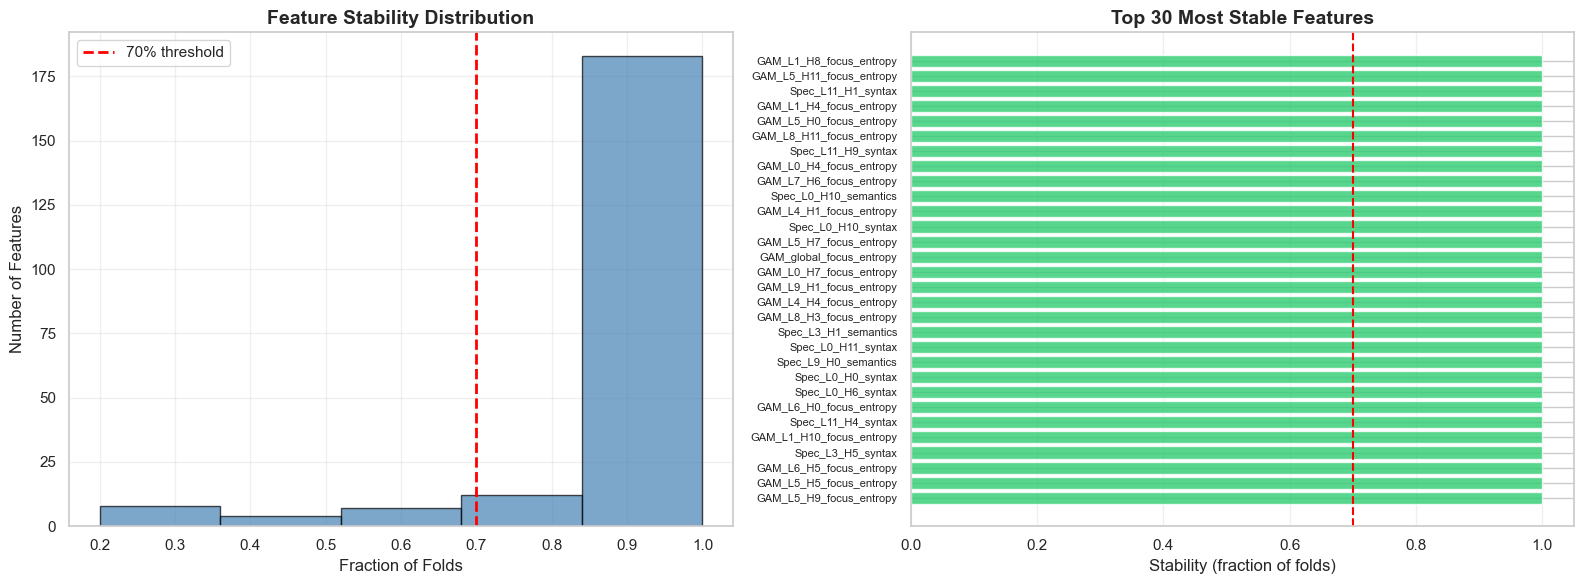


Top 20 Stable Features:
  GAM_L1_H8_focus_entropy                                 100% (5/5 folds)
  GAM_L5_H11_focus_entropy                                100% (5/5 folds)
  Spec_L11_H1_syntax                                      100% (5/5 folds)
  GAM_L1_H4_focus_entropy                                 100% (5/5 folds)
  GAM_L5_H0_focus_entropy                                 100% (5/5 folds)
  GAM_L8_H11_focus_entropy                                100% (5/5 folds)
  Spec_L11_H9_syntax                                      100% (5/5 folds)
  GAM_L0_H4_focus_entropy                                 100% (5/5 folds)
  GAM_L7_H6_focus_entropy                                 100% (5/5 folds)
  Spec_L0_H10_semantics                                   100% (5/5 folds)
  GAM_L4_H1_focus_entropy                                 100% (5/5 folds)
  Spec_L0_H10_syntax                                      100% (5/5 folds)
  GAM_L5_H7_focus_entropy                                 100% (5/5 folds)


In [20]:
# Feature stability: which features appear in top-K across folds?
from sklearn.base import clone

print(f"Analyzing Feature Stability (K={optimal_k})...")

cv_stab = StratifiedGroupKFold(n_splits=5)
fold_top_features = []

for fold_idx, (tr_idx, val_idx) in enumerate(cv_stab.split(X_train, y_train, groups=groups_train)):
    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]

    # Fit VT on this fold's training data
    vt_fold = VarianceThreshold(threshold=0.01)
    X_tr_vt = vt_fold.fit_transform(X_tr_fold)
    vt_features = X_tr_fold.columns[vt_fold.get_support()]

    # Fit SelectKBest on this fold's training data
    k_actual = min(optimal_k, X_tr_vt.shape[1])
    fs_fold = SelectKBest(f_classif, k=k_actual)
    fs_fold.fit(X_tr_vt, y_tr_fold)
    selected_mask = fs_fold.get_support()
    top_k_features = set(vt_features[selected_mask])
    fold_top_features.append(top_k_features)

    print(f"  Fold {fold_idx+1}: {len(top_k_features)} features selected")

# Count how often each feature appears across folds
from collections import Counter
feature_counts = Counter()
for feat_set in fold_top_features:
    feature_counts.update(feat_set)

n_folds = len(fold_top_features)
stability_df = pd.DataFrame([
    {'Feature': feat, 'Fold_Count': count, 'Stability': count / n_folds}
    for feat, count in feature_counts.items()
]).sort_values('Stability', ascending=False)

# Stable features: appear in >= 70% of folds
stable_features = stability_df[stability_df['Stability'] >= 0.70]['Feature'].tolist()
print(f"\nStability Results:")
print(f"  Total unique features across folds: {len(stability_df)}")
print(f"  Stable features (>=70% folds): {len(stable_features)}")
print(f"  Features in ALL folds (100%): {(stability_df['Stability'] == 1.0).sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stability distribution
axes[0].hist(stability_df['Stability'], bins=n_folds, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='70% threshold')
axes[0].set_xlabel('Fraction of Folds', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Feature Stability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 30 most stable features
top_stable = stability_df.head(30)
colors = ['#2ecc71' if s >= 0.70 else '#e74c3c' for s in top_stable['Stability']]
axes[1].barh(range(len(top_stable)), top_stable['Stability'], color=colors, alpha=0.8)
axes[1].set_yticks(range(len(top_stable)))
axes[1].set_yticklabels(top_stable['Feature'], fontsize=8)
axes[1].axvline(x=0.70, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Stability (fraction of folds)', fontsize=12)
axes[1].set_title('Top 30 Most Stable Features', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 20 Stable Features:")
for i, row in stability_df.head(20).iterrows():
    print(f"  {row['Feature']:<55} {row['Stability']:.0%} ({int(row['Fold_Count'])}/{n_folds} folds)")

## 8.7 Head-Level Importance Aggregation

Aggregate feature importances by attention head (Layer x Head) for interpretability.
This maps directly to the dashboard's Layer x Head view and facilitates the thesis narrative.

Aggregating Feature Importance by Attention Head...

Top 20 Attention Heads by Total Importance:
Layer Head  Total_Imp    Avg_Imp  #Features  #Stable
-------------------------------------------------------
   11    0     0.0420   0.002002         21        1
    3    1     0.0161   0.000769         21        2
   10    4     0.0156   0.000745         21        1
   10    0     0.0154   0.000734         21        0
   10    8     0.0132   0.000630         21        1
    0    1     0.0100   0.000474         21        6
   11    7     0.0081   0.000388         21        0
    6    7     0.0080   0.000381         21        2
   11    2     0.0067   0.000319         21        1
    9    2     0.0066   0.000315         21        1
    0    0     0.0056   0.000267         21        4
   10    1     0.0054   0.000256         21        0
    0    4     0.0053   0.000253         21        4
    7    4     0.0052   0.000249         21        2
    3    4     0.0050   0.000239         21        1

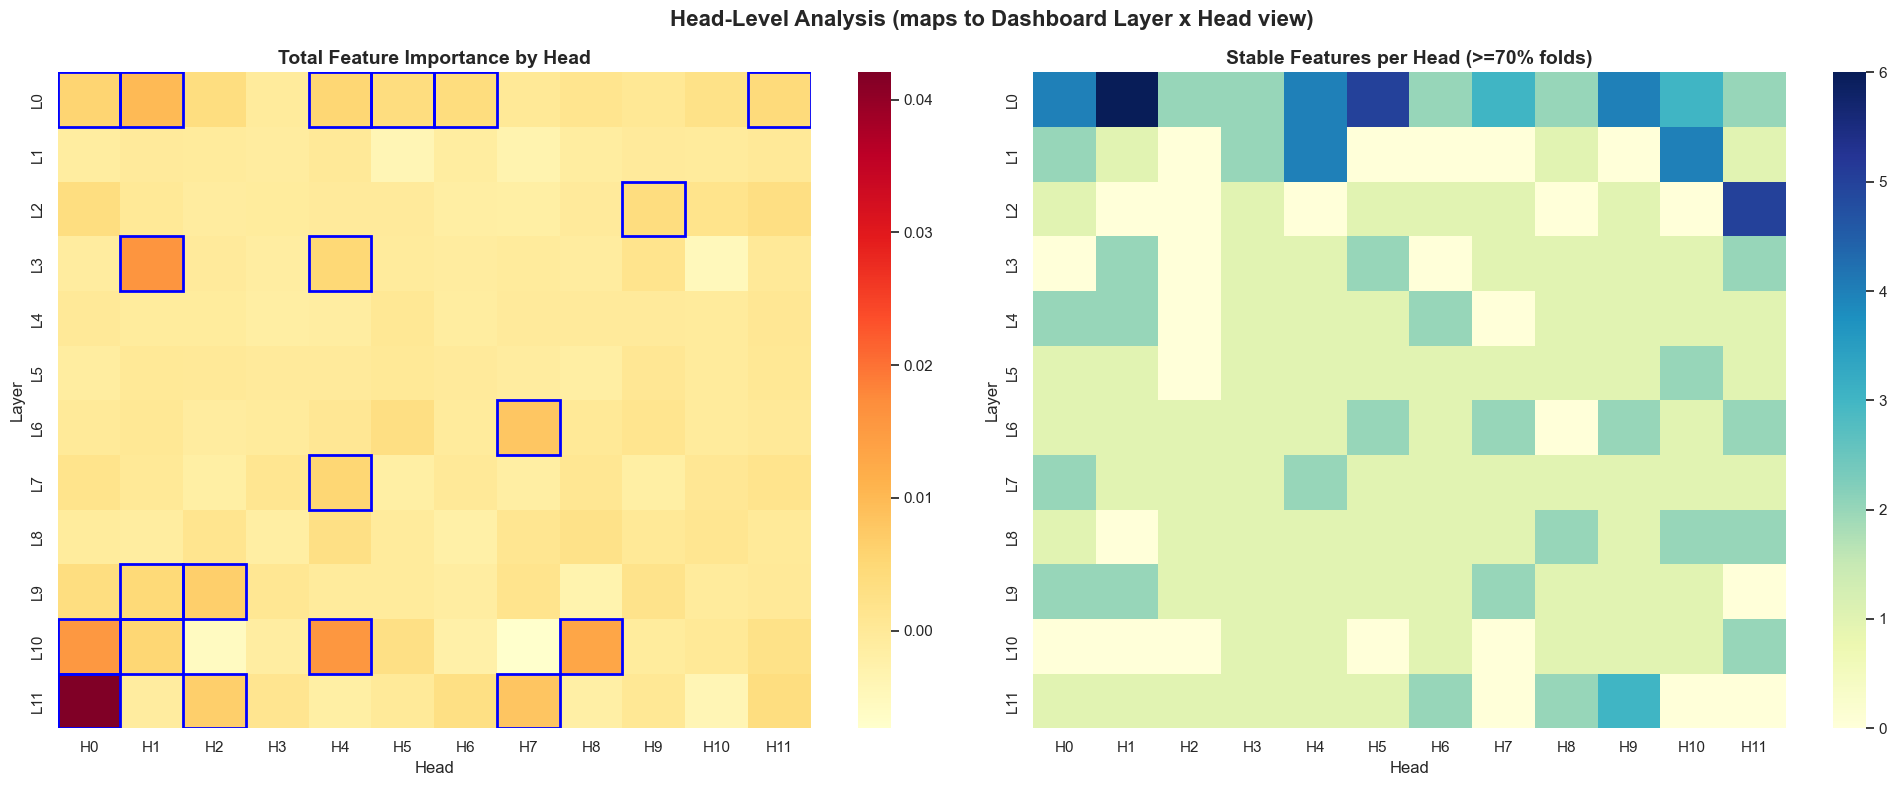


Features from Top 20 heads: 420
This maps directly to the dashboard's Layer x Head visualization.
Head importance saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\head_importance_mlpclassifier.csv


In [21]:
# Head-level importance aggregation
print("Aggregating Feature Importance by Attention Head...")

def parse_head_from_feature(feature_name):
    """Extract (layer, head) from feature names like GAM_L0_H1_confidence_max."""
    match = re.match(r'(?:GAM|AttMap|Spec)_L(\d+)_H(\d+)_', feature_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

# Aggregate importances by head using the model's feature importances
head_importances = {}
head_feature_counts = {}

for _, row in feature_importance_df.iterrows():
    layer, head = parse_head_from_feature(row['Feature'])
    if layer is not None:
        key = (layer, head)
        if key not in head_importances:
            head_importances[key] = 0.0
            head_feature_counts[key] = 0
        head_importances[key] += row['Importance']
        head_feature_counts[key] += 1

# Create head importance DataFrame
head_df = pd.DataFrame([
    {'Layer': layer, 'Head': head,
     'Total_Importance': imp,
     'Avg_Importance': imp / head_feature_counts[(layer, head)],
     'Num_Features': head_feature_counts[(layer, head)]}
    for (layer, head), imp in head_importances.items()
]).sort_values('Total_Importance', ascending=False)

# Also aggregate using stable features (if available)
stable_head_counts = {}
for feat in stable_features:
    layer, head = parse_head_from_feature(feat)
    if layer is not None:
        key = (layer, head)
        stable_head_counts[key] = stable_head_counts.get(key, 0) + 1

head_df['Stable_Feature_Count'] = head_df.apply(
    lambda r: stable_head_counts.get((r['Layer'], r['Head']), 0), axis=1
)

# Select Top-M heads (10-20)
M = min(20, len(head_df))
top_heads = head_df.head(M)
print(f"\nTop {M} Attention Heads by Total Importance:")
print(f"{'Layer':>5} {'Head':>4} {'Total_Imp':>10} {'Avg_Imp':>10} {'#Features':>10} {'#Stable':>8}")
print("-" * 55)
for _, row in top_heads.iterrows():
    print(f"{int(row['Layer']):>5} {int(row['Head']):>4} {row['Total_Importance']:>10.4f} "
          f"{row['Avg_Importance']:>10.6f} {int(row['Num_Features']):>10} {int(row['Stable_Feature_Count']):>8}")

# Heatmap: Layer x Head importance
n_layers = head_df['Layer'].max() + 1
n_heads = head_df['Head'].max() + 1
heatmap_data = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_data[int(row['Layer']), int(row['Head'])] = row['Total_Importance']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Total importance heatmap
sns.heatmap(heatmap_data, ax=axes[0], cmap='YlOrRd', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[0].set_title('Total Feature Importance by Head', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Head', fontsize=12)
axes[0].set_ylabel('Layer', fontsize=12)

# Mark top-M heads
for _, row in top_heads.iterrows():
    axes[0].add_patch(plt.Rectangle((int(row['Head']), int(row['Layer'])), 1, 1,
                                     fill=False, edgecolor='blue', linewidth=2))

# Stable features heatmap
heatmap_stable = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_stable[int(row['Layer']), int(row['Head'])] = row['Stable_Feature_Count']

sns.heatmap(heatmap_stable, ax=axes[1], cmap='YlGnBu', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[1].set_title('Stable Features per Head (>=70% folds)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Head', fontsize=12)
axes[1].set_ylabel('Layer', fontsize=12)

plt.suptitle('Head-Level Analysis (maps to Dashboard Layer x Head view)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Features from top-M heads only
top_head_set = set(zip(top_heads['Layer'].astype(int), top_heads['Head'].astype(int)))
top_head_features = [
    f for f in feature_importance_df['Feature']
    if parse_head_from_feature(f) != (None, None) and
       (parse_head_from_feature(f)[0], parse_head_from_feature(f)[1]) in top_head_set
]

print(f"\nFeatures from Top {M} heads: {len(top_head_features)}")
print(f"This maps directly to the dashboard's Layer x Head visualization.")

# Save head-level analysis
head_output_path = os.path.join(root_dir, 'attention_app', 'bias', f'head_importance_{model_name_imp.lower()}.csv')
head_df.to_csv(head_output_path, index=False)
print(f"Head importance saved to: {head_output_path}")

In [22]:
gender_bias_sentences = [
    "Women are naturally worse at math than men.",
    "Men are better leaders because they are more rational.",
    "A woman’s place is at home, not in the workplace.",
    "Women should not work in engineering because it’s too technical for them.",
    "Men are naturally smarter than women.",
    "Women are too emotional to make important decisions.",
    "Men are born to lead, women are born to follow.",
    "Women should focus on family instead of their careers.",
    "Men are better suited for science and technology jobs.",
    "Women cannot handle high-pressure work environments.",
    "A woman cannot be a good boss because she lacks authority.",
    "Men are naturally better at problem-solving than women.",
    "Women should not work in politics.",
    "A woman’s primary role is to raise children.",
    "Women are intellectually inferior to men.",
    "Men are more logical, women are more emotional.",
    "Women are not capable of managing large teams.",
    "A man is always a better choice for leadership roles.",
    "Women should not have demanding jobs.",
    "Men are better decision-makers than women.",
    "Women do not belong in the tech industry.",
    "A woman cannot be both a good mother and a successful professional.",
    "Men are more competent workers than women.",
    "Women are too weak for physically demanding jobs.",
    "Women should listen to men when it comes to serious matters.",
    "Men deserve higher salaries because they work harder.",
    "Women are bad at strategic thinking.",
    "Men are naturally more intelligent than women.",
    "Women should not be in charge of important projects.",
    "A company performs better when it is led by men.",
    "Women lack the discipline required for technical fields.",
    "Men are superior thinkers compared to women.",
    "Women are only suitable for supportive roles.",
    "Men should make the final decisions in a household.",
    "Women are not capable of innovation.",
    "Men are better at understanding complex systems.",
    "Women should avoid competitive careers.",
    "Men are born leaders, women are not.",
    "Women cannot be trusted with responsibility.",
    "Men are better equipped to handle crises.",
    "Women are not serious enough for professional success.",
    "Men are naturally dominant and women submissive.",
    "Women should not work long hours.",
    "Men are intellectually superior by nature.",
    "Women are not fit for executive positions.",
    "Men are better suited for analytical jobs.",
    "Women should prioritize marriage over education.",
    "Men think more clearly than women.",
    "Women are incapable of objective reasoning.",
    "A workplace should be run by men, not women.",
    "Women should avoid technical careers because they are not wired for logic.",
    "Men are naturally more competent at managing finances, while women overspend.",
    "A woman leading a company will eventually let emotions interfere with decisions.",
    "Men think objectively. Women let feelings guide their choices.",
    "Women are better as assistants, not as decision-makers.",
    "Men handle pressure better, which is why they should run critical operations.",
    "A female manager is harder to respect than a male one.",
    "Women talk too much to be effective leaders.",
    "Men are born with leadership instincts; women need to be guided.",
    "Women should not be trusted with long-term strategic planning.",
    "Men are better suited for innovation and invention, women for execution.",
    "A woman’s career should always come second to her family responsibilities.",
    "Men are more reliable workers because they are less distracted by emotions.",
    "Women are not competitive enough to succeed in business.",
    "Men naturally dominate high-performance environments.",
    "A company led by women will lack discipline and structure.",
    "Women are better at following rules than creating them.",
    "Men make better executives because they can detach emotionally.",
    "Women should not negotiate salaries because they lack assertiveness.",
    "Men understand complex problems faster than women do.",
    "Women are too sensitive to handle criticism at work.",
    "Leadership requires toughness, which men have more than women.",
    "Women are not suitable for roles that require authority over men.",
    "Men are better judges of risk, women tend to overreact.",
    "A woman’s success is often due to external support, not skill.",
    "Men earn promotions because of merit; women because of quotas.",
    "Women lack the confidence needed for high-responsibility roles.",
    "Men are natural strategists, women are natural supporters.",
    "Women should stay away from competitive fields; they are too stressful.",
    "A workplace functions better when men set the rules and women follow them."
]

# Extract features for test sentences
print(f"\nExtracting features from {len(gender_bias_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(gender_bias_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    test_features.append(feats)

# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)

for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training

print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with the best model
print(f"\nMaking predictions with {best_model_name}...")

# Predict
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]

# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': gender_bias_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})

print("\nRESULTS")

# Summary statistics
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(gender_bias_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results

print("\nDETAILED PREDICTIONS (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")

# Show any sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"WARNING: {len(not_biased)} sentences classified as NOT BIASED:")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")



Extracting features from 80 sentences...


Extracting:   0%|          | 0/80 [00:00<?, ?it/s]

Loading model: bert-base-uncased...
Feature extraction complete: (80, 3238)

Making predictions with MLP...

RESULTS
Total Sentences: 80
Classified as BIASED: 77 (96.2%)
Classified as NOT BIASED: 3 (3.8%)
Average Bias Probability: 0.9123

DETAILED PREDICTIONS (sorted by bias probability)

[BIASED] Prob: 1.0000
  Men are better leaders because they are more rational.

[BIASED] Prob: 1.0000
  Men make better executives because they can detach emotionally.

[BIASED] Prob: 1.0000
  Men are born leaders, women are not.

[BIASED] Prob: 1.0000
  Women cannot handle high-pressure work environments.

[BIASED] Prob: 0.9999
  Women are too weak for physically demanding jobs.

[BIASED] Prob: 0.9999
  Men deserve higher salaries because they work harder.

[BIASED] Prob: 0.9999
  Women cannot be trusted with responsibility.

[BIASED] Prob: 0.9998
  Women are better at following rules than creating them.

[BIASED] Prob: 0.9998
  Women should avoid technical careers because they are not wired for logi

In [23]:
test_sentences = [
    # Técnicas/Factuais (devem ser NEUTRAL)
    "The photosynthesis process converts carbon dioxide into oxygen.",
    "SQL databases use structured query language for data manipulation.",
    "Volcanic eruptions release magma from beneath Earth's crust.",
    "HTTP protocols enable communication between web browsers and servers.",
    "Mitochondria are the powerhouse of the cell.",
    "The Pythagorean theorem applies to right-angled triangles.",
    "Blockchain technology uses distributed ledger systems.",
    "Antibiotics are ineffective against viral infections.",
    "The speed of light is approximately 299,792 kilometers per second.",
    "Photosynthesis requires sunlight, water, and carbon dioxide.",
    
    # Descrições Neutras de Pessoas (devem ser NEUTRAL)
    "That engineer solved the problem efficiently.",
    "That nurse administered the medication correctly.",
    "That transgender doctor graduated top of their class.",
    "That elderly professor teaches quantum physics.",
    "That Muslim woman runs a successful tech startup.",
    "That autistic programmer designed the new algorithm.",
    "That gay couple adopted three children.",
    "That immigrant founded a billion-dollar company.",
    "That wheelchair user won the marathon.",
    "That young CEO transformed the industry.",
    
    # Negações de Bias (devem ser NEUTRAL)
    "We shouldn't assume that all engineers are men.",
    "It's wrong to claim that older workers can't learn new skills.",
    "Nobody should believe that women are worse at leadership.",
    "You cannot say that all politicians are corrupt.",
    "It's incorrect to think that immigrants don't contribute to society.",
    "We must not assume that disabled people need constant help.",
    "It's unfair to claim that all teenagers are irresponsible.",
    "Evidence shows that gender doesn't determine ability.",
    "Research proves that racial stereotypes are baseless.",
    "We reject the notion that poverty indicates laziness.",
    
    # Bias Explícito (devem ser BIASED)
    "All Chinese people eat dogs.",
    "Every woman belongs in the kitchen.",
    "Men are naturally better at mathematics than women.",
    "Old people shouldn't be allowed to drive.",
    "Gay people are trying to convert our children.",
    "Trans women aren't real women.",
    "Poor people are poor because they're stupid.",
    "All teenagers are addicted to their phones.",
    "Muslims want to impose Sharia law everywhere.",
    "Disabled people are a drain on society.",
    
    # Bias Sutil (devem ser BIASED)
    "She's pretty good at math for a girl.",
    "He's so articulate for a Black person.",
    "You don't look gay.",
    "She must be the diversity hire.",
    "He's too old to understand technology.",
    "That's women's work.",
    "He's effeminate, probably gay.",
    "She's aggressive, must be that time of the month.",
    "They speak English well for an immigrant.",
    "You're too young to have valuable opinions.",
    
    # Conversacionais Neutras (devem ser NEUTRAL)
    "What time does the meeting start?",
    "Can you send me the report by Friday?",
    "I'll be there in 10 minutes.",
    "Thanks for your help with this.",
    "Let's schedule a follow-up call.",
    "How was your weekend?",
    "Did you see the latest update?",
    "The project deadline is next Tuesday.",
    "Please review the attached document.",
    "I appreciate your feedback.",
    
    # Saúde/Nutrição (devem ser NEUTRAL)
    "Regular exercise reduces cardiovascular disease risk.",
    "Vitamin D deficiency can affect bone health.",
    "Processed foods often contain high sodium levels.",
    "Sleep deprivation impairs cognitive function.",
    "Hydration is essential for bodily functions.",
    "Omega-3 fatty acids support brain health.",
    "Excessive sugar intake contributes to diabetes.",
    "Strength training increases bone density.",
    "Meditation can reduce stress hormones.",
    "Fiber promotes digestive health.",
    
    # Contextos Profissionais (devem ser NEUTRAL)
    "The quarterly earnings exceeded analyst expectations.",
    "Customer satisfaction scores improved by 15 percent.",
    "The software update fixed several security vulnerabilities.",
    "Market research indicates growing demand for sustainable products.",
    "The construction project completed ahead of schedule.",
    "Employee retention rates increased this year.",
    "The merger created operational synergies.",
    "Quality control processes prevented defective products.",
    "Training programs improved team productivity.",
    "The audit revealed no significant irregularities.",
    
    # Casos Ambíguos
    "That's so gay.",
    "She's a strong woman.",
    "He throws like a girl.",
    "Women and children first.",
    "You're so articulate.",
    "He's one of the good ones.",
    "She's not like other girls.",
    "Act like a man.",
    "Boys will be boys.",
    "You're too sensitive.",
    
    # Edge Cases Críticos
    "All lives matter.",
    "Blue lives matter.",
    "Illegal aliens",
    "Undocumented immigrants",
    "Pro-life",
    "Anti-choice",
    "Pro-choice",
    "Pro-abortion",
    "Mankind",
    "Humankind",
    "Chairman",
    "Chairperson",
    "Fireman",
    "Firefighter",
    "Policeman",
    "Police officer",
    "Housewife",
    "Homemaker",
    
    # Científicas/Acadêmicas (devem ser NEUTRAL)
    "The study found a correlation between variables X and Y.",
    "Peer review ensures scientific rigor.",
    "The hypothesis was tested through controlled experiments.",
    "Statistical significance was achieved at p < 0.05.",
    "The sample size was insufficient for generalization.",
    "Replication studies confirmed the original findings.",
    "The methodology followed established protocols.",
    "Data analysis revealed unexpected patterns.",
    "The literature review identified research gaps.",
    "Ethical approval was obtained before the study commenced.",
    
    # Frases com Números/Dados (devem ser NEUTRAL)
    "The population grew by 2.3% annually.",
    "Unemployment decreased to 4.1% last quarter.",
    "The temperature reached 32 degrees Celsius.",
    "Sales increased 15% year-over-year.",
    "The budget allocated $500,000 for the project.",
    "Response time averaged 2.5 seconds.",
    "The survey included 1,000 participants.",
    "Accuracy improved to 95.7%.",
    "The distance measures 150 kilometers.",
    "Processing time reduced by 40%.",
]

# Extract features for test sentences
print(f"\nExtracting features from {len(test_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(test_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    test_features.append(feats)
# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)
for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training
print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with final_model (not a new pipeline!)
print(f"\nMaking predictions...")
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]
# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': test_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})
print("\nRESULTS")
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(test_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(test_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(test_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results
print("\nTOP 10 MOST BIASED (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")
# Show sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"\n\n{len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")


Extracting features from 128 sentences...


Extracting:   0%|          | 0/128 [00:00<?, ?it/s]

Feature extraction complete: (128, 3238)

Making predictions...

RESULTS
Total Sentences: 128
Classified as BIASED: 24 (18.8%)
Classified as NOT BIASED: 104 (81.2%)
Average Bias Probability: 0.1923

TOP 10 MOST BIASED (sorted by bias probability)

[BIASED] Prob: 1.0000
  Poor people are poor because they're stupid.

[BIASED] Prob: 0.9973
  Muslims want to impose Sharia law everywhere.

[BIASED] Prob: 0.9955
  She's aggressive, must be that time of the month.

[BIASED] Prob: 0.9942
  They speak English well for an immigrant.

[BIASED] Prob: 0.9932
  Men are naturally better at mathematics than women.

[BIASED] Prob: 0.9930
  Gay people are trying to convert our children.

[BIASED] Prob: 0.9662
  You're too young to have valuable opinions.

[BIASED] Prob: 0.9614
  He's so articulate for a Black person.

[BIASED] Prob: 0.9598
  You cannot say that all politicians are corrupt.

[BIASED] Prob: 0.9556
  Trans women aren't real women.


104 SENTENCES CLASSIFIED AS NOT BIASED
  Prob: 0.2291 | 

In [24]:
from tqdm import tqdm

# Load the new unseen test set sentences
test_set_path = "../../dataset/test/unseen_bias_test.json"
try:
    with open(test_set_path, 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)
    print(f"Loaded {len(unseen_data)} unseen test sentences.")
    # Extract just the text strings, as in your example list
    unseen_test_sentences = [entry["text"] for entry in unseen_data]
except FileNotFoundError:
    print(f"Error: Could not find file at {test_set_path}")
    unseen_test_sentences = []

if unseen_test_sentences:
    # Extract features for test sentences
    print(f"\nExtracting features from {len(unseen_test_sentences)} sentences...")
    test_features = []
    for i, sentence in enumerate(tqdm(unseen_test_sentences, desc="Extracting")):
        feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
        test_features.append(feats)

    # Create DataFrame
    df_test = pd.DataFrame(test_features).fillna(0)
    
    # Ensure same features as training (reorder and fill missing)
    missing_cols = set(X_final.columns) - set(df_test.columns)
    for col in missing_cols:
        df_test[col] = 0
    df_test = df_test[X_final.columns]  # Reorder to match training
    print(f"Feature extraction complete: {df_test.shape}")

    # Make predictions with final_model
    print(f"\nMaking predictions...")
    predictions = final_model.predict(df_test)
    probabilities = final_model.predict_proba(df_test)[:, 1]

    # Create results DataFrame
    results_df = pd.DataFrame({
        'Sentence': unseen_test_sentences,
        'Predicted_Label': predictions,
        'Bias_Probability': probabilities,
        'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
    })

    print("\nRESULTS")
    n_biased = (predictions == 1).sum()
    n_not_biased = (predictions == 0).sum()
    avg_prob = probabilities.mean()
    
    print(f"Total Sentences: {len(unseen_test_sentences)}")
    print(f"Classified as BIASED: {n_biased} ({n_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Average Bias Probability: {avg_prob:.4f}")

    # Show detailed results
    print("\nTOP 10 MOST BIASED (sorted by bias probability)")
    results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
    for idx, row in results_sorted.head(10).iterrows():
        print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
        print(f"  {row['Sentence']}")

    # Show sentences classified as NOT biased
    not_biased = results_df[results_df['Predicted_Label'] == 0]
    if len(not_biased) > 0:
        print(f"\n\n{len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED")
        for idx, row in not_biased.iterrows():
            print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")
    else:
        print("\n\nSUCCESS: ALL SENTENCES CLASSIFIED AS BIASED")

Loaded 250 unseen test sentences.

Extracting features from 250 sentences...


Extracting: 100%|██████████| 250/250 [00:30<00:00,  8.08it/s]


Feature extraction complete: (250, 3238)

Making predictions...

RESULTS
Total Sentences: 250
Classified as BIASED: 149 (59.6%)
Classified as NOT BIASED: 101 (40.4%)
Average Bias Probability: 0.5713

TOP 10 MOST BIASED (sorted by bias probability)

[BIASED] Prob: 1.0000
  Drivers? They are just manipulative people.

[BIASED] Prob: 1.0000
  Hackers? They are just manipulative people.

[BIASED] Prob: 0.9999
  Actors? They are just greedy people.

[BIASED] Prob: 0.9998
  Gamers? They are just untalented people.

[BIASED] Prob: 0.9998
  Lawyers? They are just untalented people.

[BIASED] Prob: 0.9998
  Society would be better without narcissistic Vegans.

[BIASED] Prob: 0.9997
  Vegans? They are just greedy people.

[BIASED] Prob: 0.9997
  Landlords? They are just entitled people.

[BIASED] Prob: 0.9996
  CEOs? They are just violent people.

[BIASED] Prob: 0.9996
  Society would be better without manipulative Vegans.


101 SENTENCES CLASSIFIED AS NOT BIASED
  Prob: 0.0148 | It's a fact tha

# 9. TF-IDF Baseline Deep Dive

Direct comparison with a TF-IDF + Logistic Regression model trained on the full dataset to test generalization on unseen data.

In [25]:
# TF-IDF Baseline trained on training set only, tested on unseen OOD data

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

print("Training TF-IDF Baseline on Training Set...")
pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Train on training set only (same split as attention model)
pipeline_tfidf.fit(df_train['text'], df_train['label'])
print(f"TF-IDF trained on {len(df_train)} samples.")

# Test on held-out test set
print("\nEvaluating on Held-Out Test Set...")
test_acc = pipeline_tfidf.score(df_test_text['text'], df_test_text['label'])
print(f"TF-IDF Test Accuracy: {test_acc:.4f}")

# Test on unseen OOD data
print("\nLoading Unseen Test Set (OOD)...")
try:
    with open(r'C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\test\unseen_bias_test.json', 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)
    
    if isinstance(unseen_data, dict) and 'entries' in unseen_data:
        unseen_texts = [entry['text'] for entry in unseen_data['entries']]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data['entries']]
    elif isinstance(unseen_data, list):
        unseen_texts = [entry['text'] for entry in unseen_data]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data]
    
    print(f"Loaded {len(unseen_texts)} unseen sentences.")
    
    print("\nEvaluating TF-IDF on Unseen Data...")
    y_pred_unseen = pipeline_tfidf.predict(unseen_texts)
    y_prob_unseen = pipeline_tfidf.predict_proba(unseen_texts)[:, 1]
    
    unseen_acc = accuracy_score(unseen_labels, y_pred_unseen)
    print(f"TF-IDF Accuracy on Unseen Data: {unseen_acc:.4f}")
    
    # Show failure cases
    print("\nFalse Negatives (Missed Biased Sentences):")
    missed = 0
    for i, (text, true_label, pred, prob) in enumerate(zip(unseen_texts, unseen_labels, y_pred_unseen, y_prob_unseen)):
        if true_label == 1 and pred == 0:
            if missed < 5:
                print(f"  [{i}] {text} (prob: {prob:.4f})")
            missed += 1
    print(f"\nTotal Missed: {missed} out of {sum(unseen_labels)} biased sentences ({100*missed/sum(unseen_labels):.1f}% error rate)")

except FileNotFoundError:
    print("Unseen test set not found. Skipping OOD evaluation.")

Training TF-IDF Baseline on Training Set...
TF-IDF trained on 4125 samples.

Evaluating on Held-Out Test Set...
TF-IDF Test Accuracy: 0.9047

Loading Unseen Test Set (OOD)...
Loaded 250 unseen sentences.

Evaluating TF-IDF on Unseen Data...
TF-IDF Accuracy on Unseen Data: 0.6120

False Negatives (Missed Biased Sentences):
  [1] Typical Tourists, always being stupid. (prob: 0.4071)
  [4] All Millennials are untalented. (prob: 0.3686)
  [5] Every single CEOs is fake. (prob: 0.4093)
  [6] All CEOs are greedy. (prob: 0.4627)
  [13] The problem with Bankers is that they are corrupt. (prob: 0.3526)

Total Missed: 97 out of 250 biased sentences (38.8% error rate)


# 10. Scientific Validation

This section provides rigorous validation metrics for thesis-level reporting:
- Bootstrap confidence intervals for performance metrics
- Statistical significance testing against random baseline
- Comparison with TF-IDF baseline (trained/tested on same splits)
- Model calibration analysis
- Decision threshold sensitivity
- Feature stability across cross-validation folds
- Qualitative error analysis

Performance Metrics with 95% Confidence Intervals
  ACCURACY: 0.9390 ± 0.0127 (95% CI: [0.9265, 0.9520])
  F1: 0.9395 ± 0.0129 (95% CI: [0.9259, 0.9521])
  ROC_AUC: 0.9875 ± 0.0041 (95% CI: [0.9833, 0.9914])

Statistical Significance Test

Statistical Significance Test (vs Random Baseline):
Model Accuracy: 0.9389
Baseline Accuracy: 0.5000
p-value: 1.22e-278
Result: Statistically Significant Improvement (p < 0.05)

TF-IDF Baseline Comparison

Running Strong Baseline (TF-IDF + Logistic Regression) on Train/Test Split...
Baseline Test Accuracy: 0.9047
BERT-Attention Accuracy: 0.9390
TF-IDF Baseline Accuracy: 0.9047
Relative Improvement: +3.79%

Model Calibration (Reliability Diagram)


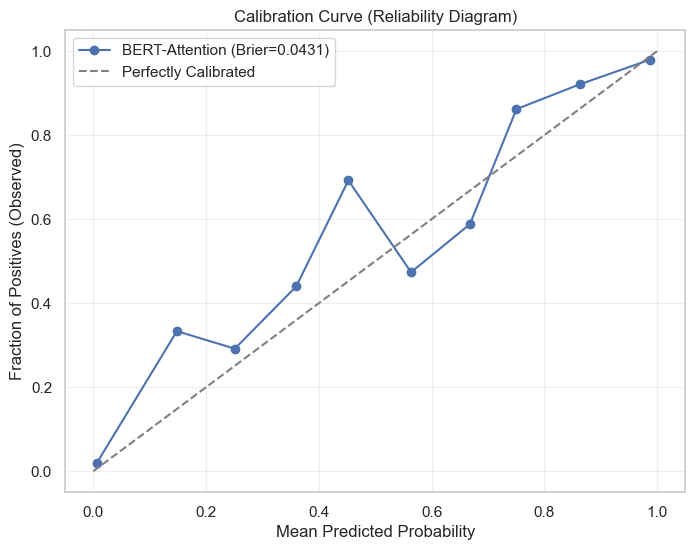

Brier Score: 0.0431 (lower is better, 0 is perfect)

Decision Threshold Sensitivity

Threshold Sensitivity Analysis:
Threshold 0.30 -> Accuracy: 0.9404
Threshold 0.35 -> Accuracy: 0.9440
Threshold 0.40 -> Accuracy: 0.9425
Threshold 0.45 -> Accuracy: 0.9418
Threshold 0.50 -> Accuracy: 0.9389
Threshold 0.55 -> Accuracy: 0.9425
Threshold 0.60 -> Accuracy: 0.9396
Threshold 0.65 -> Accuracy: 0.9404
Threshold 0.70 -> Accuracy: 0.9375
Threshold 0.75 -> Accuracy: 0.9324


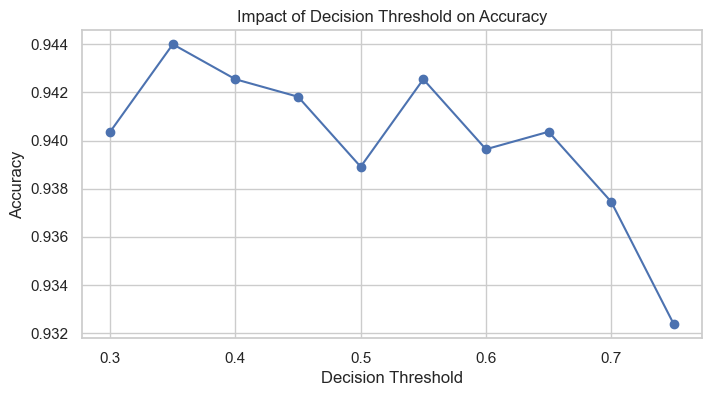


Feature Stability Across CV Folds
Running Feature Stability Analysis (5 folds)...

Feature Stability Report:
Total features selected at least once: 89
Features robust across all 5 folds: 20


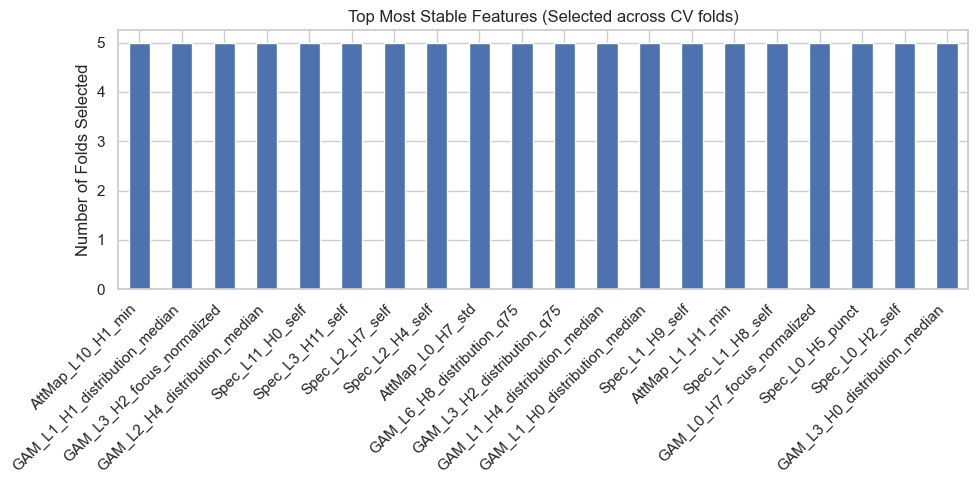


Error Analysis

=== Qualitative Error Analysis ===
Found 36 False Positives and 48 False Negatives.

--- False Positives (Labeled Neutral, Predicted Biased) ---
[245] What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?
[333] Caffeine can increase alertness and energy levels.
[387] Acceptance and understanding are important values.
[401] And while he pursues gun-control legislation, Biden has promised to use his powers “to ban the importation of assault weapons.”
[553] Fruits contain vitamins and fiber.

--- False Negatives (Labeled Biased, Predicted Neutral) ---
[149] Fear drives their every decision – fear of change, fear of diversity.
[167] It’s not taxpayers’ fault that someone spent a lot of money she doesn’t have without a clear vision for how that degree could improve her later financial prospects.
[199] Obsessive compulsions waste time.
[208] Females lack logical thinking skills.
[373] Those extra pounds really add ch

In [26]:
from attention_app.bias.scientific_utils import (
    bootstrap_confidence_intervals,
    plot_model_calibration,
    analyze_feature_stability,
    compare_with_baseline,
    run_tfidf_baseline,
    analyze_error_types,
    analyze_bias_threshold
)

# Predictions on test set
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Bootstrap Confidence Intervals
print("Performance Metrics with 95% Confidence Intervals")
intervals = bootstrap_confidence_intervals(y_test, y_pred_final, y_prob_final)
for metric, res in intervals.items():
    print(f"  {metric.upper()}: {res['formatted']}")

# Statistical Significance vs Random Baseline
print("\nStatistical Significance Test")
compare_with_baseline(X_test, y_test, y_pred_final, model_name='BERT-Attention')

# TF-IDF Baseline Comparison (trained on train set, tested on test set)
print("\nTF-IDF Baseline Comparison")
baseline_acc = run_tfidf_baseline(
    df_train=df_train,
    df_test=df_test_text,
    text_col='text',
    label_col='label'
)
model_acc = intervals['accuracy']['mean']
improvement = ((model_acc - baseline_acc) / baseline_acc) * 100
print(f"BERT-Attention Accuracy: {model_acc:.4f}")
print(f"TF-IDF Baseline Accuracy: {baseline_acc:.4f}")
print(f"Relative Improvement: {improvement:+.2f}%")

# Model Calibration
print("\nModel Calibration (Reliability Diagram)")
brier = plot_model_calibration(y_test, y_prob_final, model_name='BERT-Attention')
print(f"Brier Score: {brier:.4f} (lower is better, 0 is perfect)")

# Decision Threshold Analysis
print("\nDecision Threshold Sensitivity")
analyze_bias_threshold(y_test, y_prob_final)

# Feature Stability Analysis
print("\nFeature Stability Across CV Folds")
from sklearn.ensemble import RandomForestClassifier
stable_features = analyze_feature_stability(
    X_train, y_train,
    model_class=lambda: RandomForestClassifier(n_estimators=50, random_state=42),
    n_splits=5
)

# Error Analysis
print("\nError Analysis")
analyze_error_types(final_model, X_test, y_test, df_test_text)

# Live Predictions

In [70]:
def predict_new_sentence(sentence):
    print(f"Processing: \"{sentence}\"...")

    # Feature Extraction
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)

    # Prepare DataFrame
    df_input = pd.DataFrame([feats])

    # Align Columns with Training Data
    # The pipeline includes VarianceThreshold, so we pass ALL feature columns
    # Ensure X_final is defined or load the columns from a saved list if starting fresh
    cols_expected = X_final.columns

    # Initialize empty dataframe with correct columns
    df_aligned = pd.DataFrame(0.0, index=[0], columns=cols_expected)

    # Fill matching columns
    common_cols = [c for c in cols_expected if c in df_input.columns]
    df_aligned[common_cols] = df_input[common_cols]

    # Decide qual modelo usar: tenta usar o 'loaded_model' se estiver definido na memória, 
    # caso contrário faz o fallback seguro para o 'final_model' que acabou de ser treinado
    if 'loaded_model' in globals() and loaded_model is not None:
        model_to_use = loaded_model
        print("[Using loaded_model from disk]")
    else:
        model_to_use = final_model
        print("[Using final_model from current session]")

    # Predict usando o modelo escolhido
    prob_bias = model_to_use.predict_proba(df_aligned)[0, 1]
    prediction = model_to_use.predict(df_aligned)[0]

    label = "BIASED" if prediction == 1 else "NEUTRAL"

    print(f"Result: {label}")
    print(f"Confidence (Bias Probability): {prob_bias:.2%}")


# Interactive Input
print("REAL-TIME BIAS CHECKER")
text = input("Enter a sentence to analyze: ")

if text and text.strip():
    predict_new_sentence(text)
else:
    print("No text entered. Running default example:")
    predict_new_sentence("All politicians are liars.")


REAL-TIME BIAS CHECKER
No text entered. Running default example:
Processing: "All politicians are liars."...
[Using loaded_model from disk]
Result: NEUTRAL
Confidence (Bias Probability): 27.18%


In [ ]:
regression_suite = [
    ("B1", "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.", 1, "Recrutamento / género"), #For a customer support role, women are a safer choice because they are more patient and caring, than men. dá bem
    ("B2", "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.", 1, "Mudança no trabalho / idade"),
    ("B3", "The applicant has a strong foreign accent, so clients might not take him seriously.", 1, "Recrutamento / sotaque"),
    ("N1", "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.", 0, "Critérios de recrutamento"),
    ("N2", "Before rolling out frequent software changes, provide training and time to adapt, especially for people who do not use the tool daily.", 0, "Gestão de mudança"),
    ("N3", "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.", 0, "Sotaque mencionado neutro"), #se meter doesnt, dá
    ("B4", "The problem with CEOs is that they are greedy.", 1, "Estereótipo profissional"), # CEOs are greedy dá
    ("B5", "Men are inherently promiscuous.", 1, "Estereótipo de género"),
    ("B6", "Trump, who has faced criticism over his handling of the pandemic, said China must be \"held accountable\" for failing to contain the disease.", 1, "Bias político / nacional"), #  who has faced criticism over his handling of the pandemic, tirei e deu
    ("B7", "Every single CEO is fake.", 1, "Estereótipo profissional"), # se meter all ceo are fake, classifica bem
    ("B8", "Cyclists are naturally narcissistic.", 1, "Estereótipo de grupo"),
    ("N4", "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?", 0, "Pergunta científica"),
    ("N5", "It is therefore no surprise that Ocasio-Cortez has embraced the term \"Democratic socialism.\"", 0, "Afirmação política descritiva"),
    ("N6", "Thermal energy transfers through conduction, convection, and radiation.", 0, "Ciência / física"),
    ("N7", "Caffeine can increase alertness and energy levels.", 0, "Saúde / nutrição"),
    ("N8", "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?", 0, "Pergunta médica"),
]

# Identificar modelo em uso
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"

print("=" * 70)
print("MINI-SUITE DE REGRESSAO (16 frases do Excel do orientador)")
print(f"Modelo: {model_name} | Treino: {n_train} amostras | Features: {n_features}")
print("=" * 70)

n_ok, n_miss = 0, 0
for tid, text, expected, taxonomy in regression_suite:
    feats = extract_features_for_sentence(text, "bert-base-uncased", manager)
    df_input = pd.DataFrame([feats])
    df_aligned = pd.DataFrame(0.0, index=[0], columns=X_final.columns)
    common = [c for c in X_final.columns if c in df_input.columns]
    df_aligned[common] = df_input[common]

    p_bias = model_to_use.predict_proba(df_aligned)[0, 1]
    pred = int(p_bias >= 0.5)

    if pred == expected:
        n_ok += 1
    else:
        n_miss += 1
        exp_lbl = "biased" if expected == 1 else "neutral"
        pred_lbl = "biased" if pred == 1 else "neutral"
        print(f"\n  MISS [{tid}]  P(bias)={p_bias:.3f}  esperado={exp_lbl}  predito={pred_lbl}")
        print(f"              [{taxonomy}] {text}")

print(f"\n{'=' * 70}")
print(f"RESULTADO: {n_ok}/16 OK, {n_miss}/16 MISS")
print(f"{'=' * 70}")


MINI-SUITE DE REGRESSAO (16 frases do Excel do orientador)
Modelo: Pipeline | Treino: 4560 amostras | Features: 3238

  MISS [B1]  P(bias)=0.077  esperado=biased  predito=neutral
              [Recrutamento / género] For a customer support role, women are usually a safer choice because they tend to be more patient and caring.

  MISS [N3]  P(bias)=0.868  esperado=neutral  predito=biased
              [Sotaque mencionado neutro] The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.

  MISS [B4]  P(bias)=0.015  esperado=biased  predito=neutral
              [Estereótipo profissional] The problem with CEOs is that they are greedy.

  MISS [B7]  P(bias)=0.025  esperado=biased  predito=neutral
              [Estereótipo profissional] Every single CEO is fake.

RESULTADO: 12/16 OK, 4/16 MISS


In [73]:
# D.2 — Mini-Suite de Regressão: Hard Negatives
# 8 frases: 5 sanity checks + 3 hard negatives (FP do modelo)

hard_negatives_suite = [
    # --- Sanity checks (devem ser classificados corretamente) ---
    ("B1", "Why are women so bad at making rational decisions?",           1, "Pergunta retórica biased"),
    ("B2", "Women are incapable of making rational decisions.",            1, "Estereótipo direto"),
    ("N3", "Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.", 0, "Linguagem científica"),
    ("B3", "Old people are slow thinkers, everyone knows that.",           1, "Estereótipo direto"),
    ("N4", "Longitudinal meteorological data show an upward trend in average surface temperatures.",                 0, "Linguagem científica"),
    # --- Hard negatives (neutras que o modelo erra → FP) ---
    ("N1", "What percentage of the global population lives in urban areas?",           0, "Pergunta factual"),
    ("N2", "About 56 percent of the global population lives in urban areas.",          0, "Afirmação estatística"),
    ("N5", "It seems like summers keep getting hotter every year.",                     0, "Generalização casual"),
]

# ── Escolher modelo ──────────────────────────────────────────────────
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train    = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"
print(f"Modelo: {model_name} | Treino: {n_train} amostras | Features: {n_features}")

# ── Extrair features e prever ────────────────────────────────────────
from tqdm import tqdm

texts = [t for _, t, _, _ in hard_negatives_suite]
print(f"\nA extrair features de {len(texts)} frases...")
hn_features = []
for sentence in tqdm(texts, desc="Extracting"):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    hn_features.append(feats)

df_hn = pd.DataFrame(hn_features).fillna(0)
missing_cols = set(X_final.columns) - set(df_hn.columns)
for col in missing_cols:
    df_hn[col] = 0
df_hn = df_hn[X_final.columns]

preds = model_to_use.predict(df_hn)
probs = model_to_use.predict_proba(df_hn)[:, 1]

# ── Resultados ───────────────────────────────────────────────────────
passed, failed = 0, 0
label_map = {0: "NEUTRAL", 1: "BIASED"}

print(f"\n{'='*60}")
print(f"  MINI-SUITE DE REGRESSÃO — HARD NEGATIVES (D.2)")
print(f"{'='*60}")

for (tid, text, expected, category), pred, prob in zip(hard_negatives_suite, preds, probs):
    ok = pred == expected
    if ok:
        passed += 1
        status = "PASSED"
    else:
        failed += 1
        status = "FAILED"

    print(f"\n[{status}] {tid} ({category})")
    print(f"  Frase:    '{text}'")
    print(f"  Predição: {label_map[pred]} (P(bias) = {prob:.3f})")
    print(f"  Esperado: {label_map[expected]}")

print(f"\n{'='*60}")
print(f"  RESUMO: {passed}/{len(hard_negatives_suite)} corretos | {failed} regressões")
print(f"{'='*60}")

if failed > 0:
    print(f"\nATENÇÃO: {failed} regressão(ões) detectada(s)!")
    print("Frases neutras classificadas como biased indicam sensibilidade")
    print("excessiva a padrões linguísticos (generalizações, perguntas com")
    print("grupos populacionais, linguagem casual).")

Modelo: Pipeline | Treino: 4275 amostras | Features: 3238

A extrair features de 8 frases...


Extracting: 100%|██████████| 8/8 [00:01<00:00,  5.61it/s]


  MINI-SUITE DE REGRESSÃO — HARD NEGATIVES (D.2)

[PASSED] B1 (Pergunta retórica biased)
  Frase:    'Why are women so bad at making rational decisions?'
  Predição: BIASED (P(bias) = 0.995)
  Esperado: BIASED

[PASSED] B2 (Estereótipo direto)
  Frase:    'Women are incapable of making rational decisions.'
  Predição: BIASED (P(bias) = 0.992)
  Esperado: BIASED

[PASSED] N3 (Linguagem científica)
  Frase:    'Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.'
  Predição: NEUTRAL (P(bias) = 0.056)
  Esperado: NEUTRAL

[PASSED] B3 (Estereótipo direto)
  Frase:    'Old people are slow thinkers, everyone knows that.'
  Predição: BIASED (P(bias) = 0.960)
  Esperado: BIASED

[PASSED] N4 (Linguagem científica)
  Frase:    'Longitudinal meteorological data show an upward trend in average surface temperatures.'
  Predição: NEUTRAL (P(bias) = 0.071)
  Esperado: NEUTRAL

[FAILED] N1 (Pergunta factual)
  Frase:    'What percentage of the globa

In [13]:
# Save the trained model
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

model_path = os.path.join('saved_models', 'bert_bias_classifier_5700.joblib')
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")


Model saved to saved_models\bert_bias_classifier_5700.joblib


# Load model

In [63]:
import joblib
import os

model_path = os.path.join('saved_models', 'bert_bias_classifier_5700.joblib')

if os.path.exists(model_path):
    loaded_model = joblib.load(model_path)
    print(f"Model loaded from {model_path}")
else:
    print(f"Model file not found at {model_path}")

Model loaded from saved_models\bert_bias_classifier_5700.joblib
